### Importing the dataset and necessary libraries

In [2]:
# Standard
import pandas as pd
import numpy as np

# Date-related libraries
from datetime import timedelta
from datetime import datetime
import re
from word2number import w2n
from dateutil.relativedelta import relativedelta

# Visualization
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import plotly.express as px
import seaborn as sns
import shap

# For predictions
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# Other
from cleantext import clean
import re
from array import array

In [3]:
original_dataset = pd.read_excel('Global Protest Tracker Updated.xlsx')
print(f"Number of rows: {original_dataset.shape[0]} and columns: {original_dataset.shape[1]}")
original_dataset.head(2)

Number of rows: 822 and columns: 22


,Country,Protest Name,Start Date,Freedom Rating (Status),Triggers,Motivations,Peak Size,Key Participants,Duration,Outcomes,...,Political motivation?,Corruption motivation?,Gender motivation?,Size category,Protests with a significant outcome,"Large protests (Over 100,000 protesting)",Violent government response,Long protests (more than 3 months),Coronavirus-related protests,Capital city
0,Ecuador,"Protest for ""Guayaquil Four"" boys",24-Dec,Partly Free,"Four teenage boys (the ""Guayaquil Four"") disap...",Demand justice for missing boys. Express anger...,>100,"General public, families of missing boys",Active,The nationwide protests pushed authorities to ...,...,X,NaN,NaN,Hundreds,NaN,NaN,NaN,NaN,NaN,Quito
1,Kenya,Protest against abductions of government critics,24-Dec,Partly Free,The Kenya National Commission on Human Rights ...,Denounce the extrajudicial arrests. Demand tha...,>100,"Human rights groups, youth",1 day,No policy/leadership change. Though President ...,...,X,NaN,NaN,Hundreds,NaN,NaN,NaN,NaN,NaN,Nairobi


# Data Preparation

In [4]:
# Creating a copy to work on it at later steps
data = original_dataset.copy()

# 1) =========== Dropping duplicates ==============
data = data.drop_duplicates(subset=['Protest Name', 'Motivations'])
print(f"Len before dropping duplicates: {len(original_dataset)} and len after: {len(data)}.")

# 2) ====== Handling date-related columns ========
# Converting 'Start Date' column to datetime
data['Start Date'] = pd.to_datetime(original_dataset['Start Date'], format='%y-%b', errors='coerce')

# Function to check if there is an int in a string 
def contains_number(s):
    return bool(re.search(r'\d+', s))

def convert_verbal_numbers_to_numerical(sentence):
    # Split the sentence into words
    words = sentence.split()
    
    # Process each word to convert verbal numbers to numerical
    processed_words = []
    for word in words:
        try:
            numerical_value = w2n.word_to_num(word.lower())
            processed_words.append(str(numerical_value))  # Add numerical value as string
        except ValueError:
            # If not a number, keep the word as is
            processed_words.append(word)
    
    # Join the processed words back into a sentence
    return ' '.join(processed_words)

days_list = ['day','days']
weeks_list = ['week','weeks']
months_list = ['month','months']
years_list = ['year','years']
duration_in_days = 0 # to change the duration to be the same, so in days

def calculate_duration(row):
    if row['Duration'].startswith("Active"):
        # Calculate duration in days since the start of the protest if it is still active
        start_date = pd.to_datetime(row['Start Date'])
        current_date = datetime.now()
        duration_in_days = (current_date - start_date).days
        return duration_in_days
    
    i = 0
    # Splitting by both spaces and commas
    converted_sentence = convert_verbal_numbers_to_numerical(row['Duration'])
    phrase = re.split(r'[ ,]+', converted_sentence)
    limit = len(phrase)
    new_row = row['Start Date']  # Initialize new_row to the start date in case of no duration
    duration_in_days = 0
    
    while i < limit:
        token = phrase[i]
        
        if contains_number(token):
            # Ensure there is a next element before accessing phrase[i+1]
            if i+1 < limit:
                duration_verbal = phrase[i+1]
                if duration_verbal in days_list:
                    days = int(token)  
                    duration_in_days += days
                elif duration_verbal in weeks_list:
                    try:
                        if '-' in token:  # Handling ranges like '1-2'
                            parts = token.split('-')
                            avg_value = (int(parts[0]) + int(parts[1])) / 2  # Taking the average
                            duration_in_days += avg_value * 7  
                        else:
                            duration_in_days += int(token) * 7  
                    except ValueError:
                            return None  
                elif duration_verbal in months_list:
                    months = round(float(token)) # I'm rounding 1.5 months to 2 months, for ex.
                    duration_in_days += (months*30) # I'm assuming every month has 30 days here
                elif duration_verbal in years_list:
                    years = round(float(token))
                    duration_in_days += (years*365)
        i += 1
    # Return both the new row and the calculated duration in days as a Series
    return duration_in_days

data['Duration in days'] = data.apply(calculate_duration, axis=1)

Len before dropping duplicates: 822 and len after: 809.


In [5]:
def fill_missing_durations(data):
    # Calculate the average Duration in days per country
    country_avg_durations = data.groupby('Country')['Duration in days'].mean()
    
    data['Duration in days'] = data.apply(
        lambda row: country_avg_durations[row['Country']] 
        if pd.isna(row['Duration in days']) else row['Duration in days'], axis=1
    )

    return data

data = fill_missing_durations(data)
data[['Start Date','Duration','Duration in days']]

,Start Date,Duration,Duration in days
0,2024-12-01,Active,94.0
1,2024-12-01,1 day,1.0
2,2024-12-01,1 day,1.0
3,2024-12-01,1 day,1.0
4,2024-12-01,1 day,1.0
...,...,...,...
817,2017-08-01,2 months,60.0
818,2017-04-01,"1 year, 8 months (sporadic)",605.0
819,2017-04-01,1 day,1.0
820,2017-04-01,3 months,90.0


In [6]:
data = data.drop(columns=['Duration'])

# 3) ====== Dealing with numerical values ========

dict_for_numbers = {'Thousands': 3000, 'Tens of thousands': 30000, '1 million': 1000000,
                    '1.2 million': 1200000, '1.5 million': 1500000}

def clean_peak_size(value):
    if isinstance(value, str):
        if value.startswith('>') or value.startswith('<'):
            value = value[1:]  # Remove the first character if it starts with '<'
            value = value.replace(",","")
        else:
            if value in dict_for_numbers.keys():
                value = dict_for_numbers[value]
    try:
        return int(value) if isinstance(value, str) and len(value) > 0 else value
    except (ValueError, TypeError):
        return value
    
data['Peak Size'] = data['Peak Size'].apply(clean_peak_size)

# Convert 'Peak Size' to numeric, coercing errors to NaN (non-integers will become NaN)
data['Peak Size'] = pd.to_numeric(data['Peak Size'], errors='coerce')

# Drop rows where 'Peak Size' is NaN (which means it was not an integer)
data = data.dropna(subset=['Peak Size'])

# Reset the index 
data.reset_index(drop=True, inplace=True)

# 4) ====== Dealing with categorical values ========

binary_columns = ['Active protests', 'Economic motivation?', 'Political motivation?',
                       'Corruption motivation?','Gender motivation?','Protests with a significant outcome',
                       'Large protests (Over 100,000 protesting)','Violent government response',
                       'Long protests (more than 3 months)','Coronavirus-related protests']

for column in binary_columns:
    data[column] = data[column].apply(lambda x: 1 if x == 'X' else 0)
    
size_categories = {'Tens': 0, 'Dozens': 0, 'Hundreds': 1,
                   'Thousands':2,
                   'Thosuands':2,
                   'Thousads':2,
                   'Tens of thousands':3,
                   'Tens of Thousands':3,
                   'Hundreds of thousands':4,
                   'Hundreds of of thousands':4,
                   'Huundreds of thousands':4,
                   'Over 1 million':5,
                   'Millions':5,
                   'Tens of millions':6,
                   'Unknown':-1}

def ratings(rating): 
    if rating == 'Free':
        return 1
    else:
        return 0

def size(category): 
    return size_categories[category]

data['Free'] = data['Freedom Rating (Status)'].apply(ratings)
data['Size category'] = data['Size category'].apply(size)

data[['Peak Size','Active protests','Economic motivation?','Free','Size category']]

,Peak Size,Active protests,Economic motivation?,Free,Size category
0,100.0,1,0,0,1
1,100.0,0,0,0,1
2,1000.0,0,0,0,2
3,1000.0,0,1,0,2
4,100.0,0,0,0,1
...,...,...,...,...,...
800,1000.0,0,1,0,3
801,100000.0,0,1,0,3
802,30000.0,0,1,1,2
803,200000.0,0,0,0,2


# Exploratory Data Analysis

1. Geographic representation

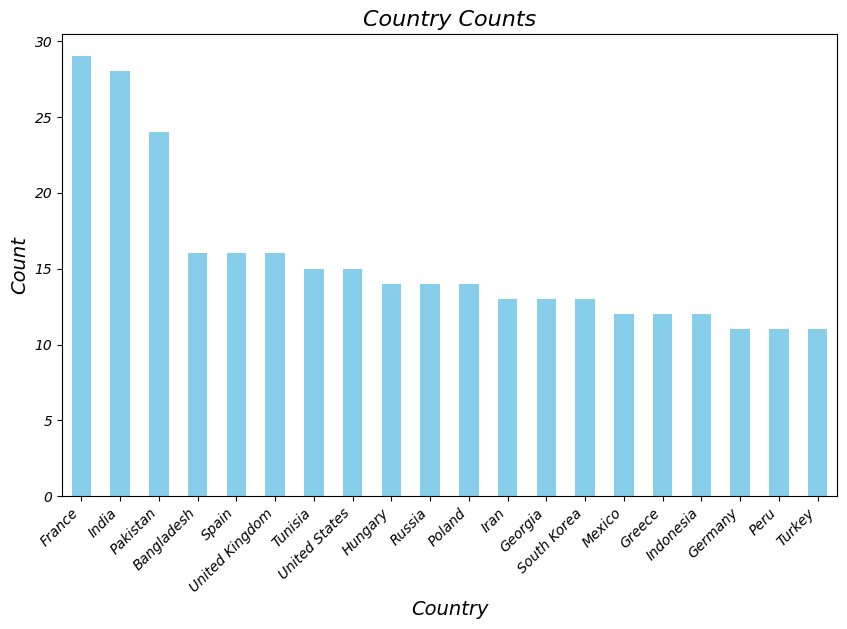

In [7]:
country_counts = data['Country'].value_counts()

# 1) ====== Classic bar chart =========
# Plotting the top 10 bar chart
plt.figure(figsize=(10, 6))  
country_counts.head(20).plot(kind='bar', color='skyblue')

plt.title('Country Counts', fontsize=16)
plt.xlabel('Country', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45, ha='right') # rotating x-axis labels for better readability
plt.show()

# 1) ====== More advanced world map =========
country_counts_df = country_counts.reset_index()
country_counts_df.columns = ['Country', 'Count']

# Create the choropleth map
fig = px.choropleth(
    country_counts_df,
    locations='Country',
    locationmode='country names',  
    color='Count',
    color_continuous_scale='viridis',
    title='Country Counts',
    labels={'Count': 'Count'}
)

# Customize the layout to remove white margins
fig.update_layout(
    title_font_size=18,
    geo=dict(showframe=False, showcoastlines=True, projection_type='natural earth'),
    margin=dict(l=0, r=0, t=40, b=0),  # Remove left and right margins
    autosize=True  # Automatically adjust the size to fill the available space
)

# Show the map
fig.show()

2. Date ranges

Latest protest date: 2016-10-01 00:00:00
Newest protest date: 2024-12-01 00:00:00


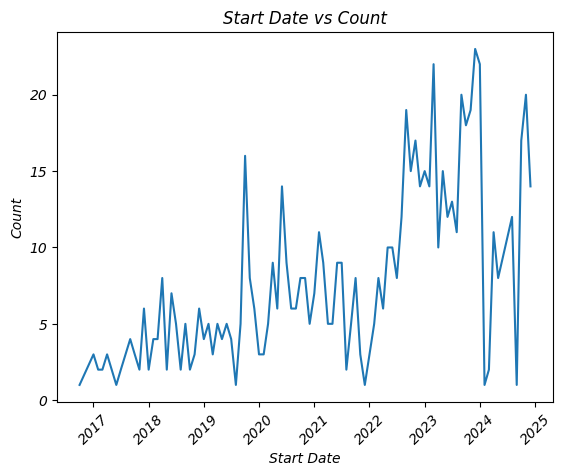

In [8]:
# 1) Year ranges
print("Latest protest date:",data['Start Date'].min())
print("Newest protest date:",data['Start Date'].max())

# 2) Protest Frequency over time
xpoints = data['Start Date'].value_counts().sort_index().index  # Unique dates (x-axis)
ypoints = data['Start Date'].value_counts().sort_index().values  # Counts (y-axis)

# Plot the data
plt.plot(xpoints, ypoints)
plt.xticks(rotation=45)  # Rotate x-axis labels if dates overlap
plt.title('Start Date vs Count')
plt.xlabel('Start Date')
plt.ylabel('Count')
plt.show()

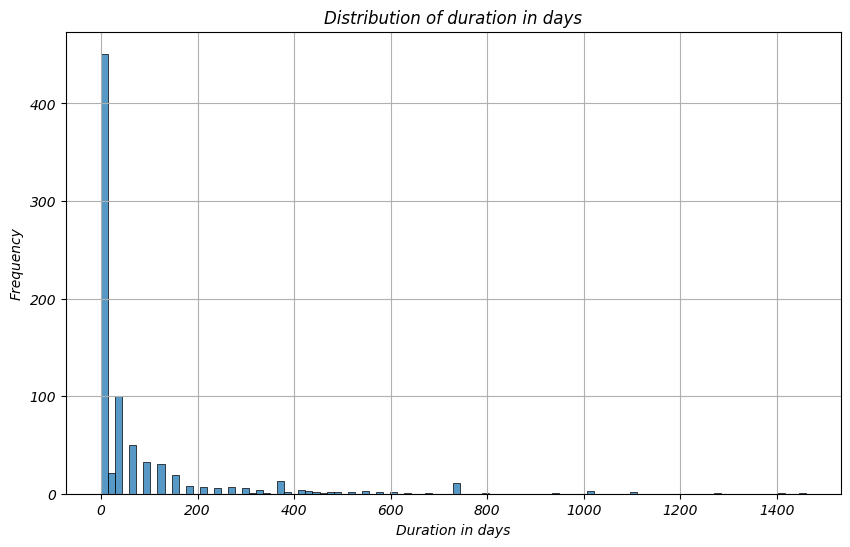

In [9]:
import seaborn as sns
# 3) Distribution of Duration
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='Duration in days', bins = 100)
plt.title('Distribution of duration in days')
plt.xlabel('Duration in days')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

4. Peak size distribution

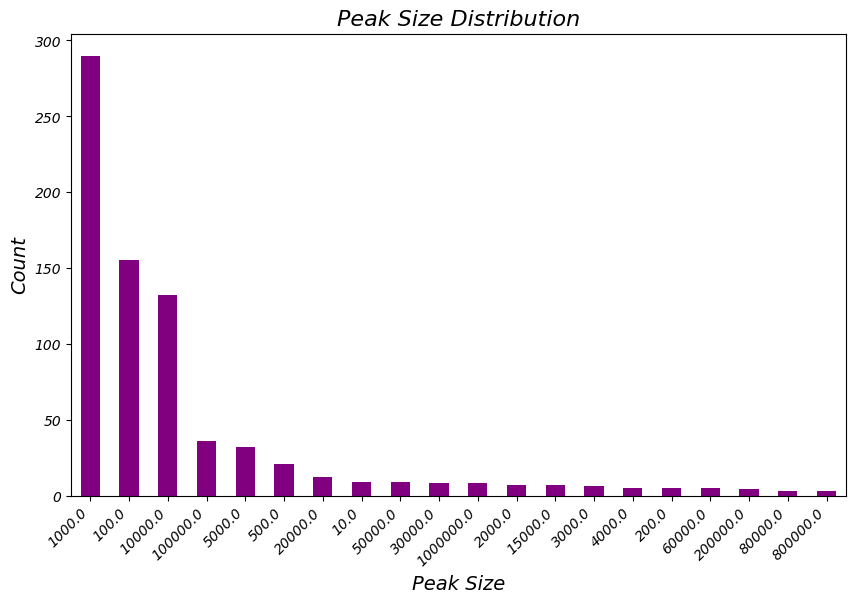

Size category
 2    360
 3    180
 1    176
 4     52
 0     22
 5     11
-1      3
 6      1
Name: count, dtype: int64

In [10]:
plt.figure(figsize=(10, 6))  
data['Peak Size'].value_counts().head(20).plot(kind='bar', color='purple')

# Add titles and labels
plt.title('Peak Size Distribution', fontsize=16)
plt.xlabel('Peak Size', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Show the plot
plt.show()

data['Size category'].value_counts()

Hence, most of the protests were in thousands (360), then tens of thousands (180) and hundreds (176). The data is less representative of protests which concerned hundreds of thousands of protesters (52), tens (22), over one million (11) and only one with tens of millions. There were three protests with an unknown size. This feature was created for a more detailed exploratory data analysis, and will be removed at a later stage for predictions. 

3. Textual data analysis

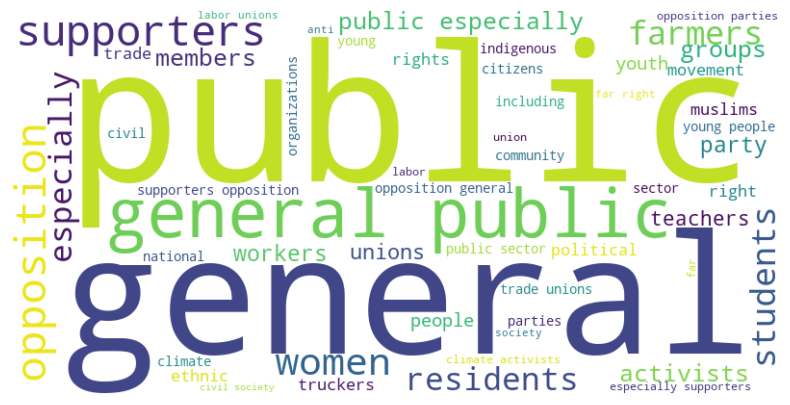

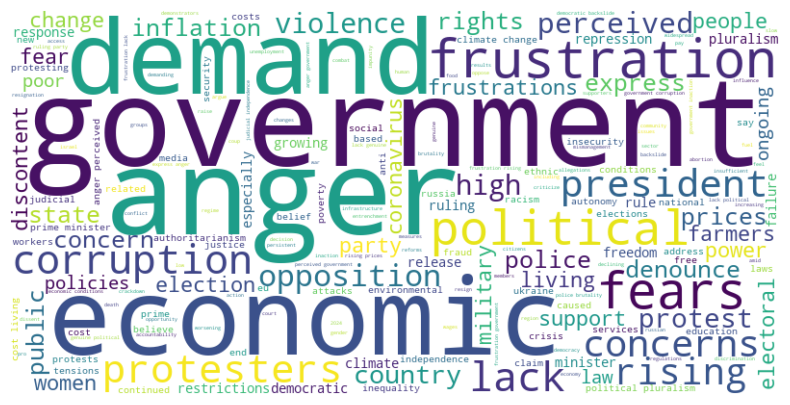

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Function to clean text for later analysis
def clean_text(text):
    # Remove non-alphanumeric characters
    text = re.sub(r'\W',' ',text)
    # Lowercase the text
    text = text.lower()
    text = ' '.join(text.split())
    return text

textual_columns = ['Protest Name', 'Key Participants','Triggers', 'Motivations','Outcomes']
tf_idf = data.copy() # Creating a dataframe with preprocessed textual data for tf-idf and leaving 'data' for transformers for more context
for column in textual_columns:
    tf_idf[column] = tf_idf[column].fillna('').astype(str).apply(clean_text)
    tf_idf[column] = tf_idf[column].apply(clean_text)

def word_cloud(data, column):
    # Using a vectorizer for a larger corpus of words to create the word cloud
    corpus = []
    for row in data[column]:
        corpus.append(row)
        
    vectorizer = TfidfVectorizer(strip_accents="ascii", lowercase=True, stop_words='english', ngram_range = (1,2), max_df = 0.99, min_df = 0.01, max_features=1000, norm = 'l2', binary = False)
    vectors = vectorizer.fit_transform(corpus)
    feature_names = vectorizer.get_feature_names_out()
    dense = vectors.todense() 
    denselist = dense.tolist() 
    df = pd.DataFrame(denselist, columns=feature_names) 
    
    # Step 1: Summing the TF-IDF values for each word (column)
    word_scores = df.sum(axis=0)

    # Step 2: Converting it to a dictionary for the WordCloud
    word_dict = word_scores.to_dict()

    # Step 3: Generate the word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_dict)

    # Step 4: Display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')  # Turn off axis
    plt.show()
    
word_cloud(tf_idf,'Key Participants')
word_cloud(tf_idf,'Motivations')

4. Categorical values analysis

In [12]:
country_counts_df

,Country,Count
0,France,29
1,India,28
2,Pakistan,24
3,Bangladesh,16
4,Spain,16
...,...,...
145,Republic of Ireland,1
146,El Salvador,1
147,Namibia,1
148,Botswana,1


In [13]:
political = round(len(data[data['Political motivation?']==1])/len(data),3)
economic = round(len(data[data['Economic motivation?']==1])/len(data),4)
corruption = round(len(data[data['Corruption motivation?']==1])/len(data),3)
gender = round(len(data[data['Gender motivation?']==1])/len(data),3)
significant = data[data['Protests with a significant outcome']==1]
large = round(len(data[data['Large protests (Over 100,000 protesting)']==1])/len(data),3)
violent = round(len(data[data['Violent government response']==1])/len(data),4)
long = round(len(data[data['Long protests (more than 3 months)']==1])/len(data),4)
free = round(len(data[data['Free']==1])/len(data),3)

print(f"{political*100}% of the protests had a political motivation.")
print(f"{economic*100}% of the protests had an economic motivation.")
print(f"{corruption*100}% of the protests had a corruption motivation.")
print(f"{gender*100}% of the protests had a gender-related motivation.")
print(f"{large*100}% of the protests had more than 100k protesters.")
print(f"{violent*100}% of the protests were met with a violent response.")
print(f"{long*100}% of the protests lasted for more than 3 months.")
print(f"{free*100}% of the protests were labeled as 'free'.")
print(f"{(round(len(significant)/len(data),2))*100}% of the protests had a significant outcome. \n")

# Analyzing the geographic distribution of protests with a significant outcome
# based on the number of protests registered in that country
significant_counts = significant['Country'].value_counts()
def calculating_ratio(row):
    country = row['Country']
    if country not in significant_counts:
        return pd.Series({'Significant Count': 0, 'Significance ratio': 0})
    else:
        #print(significant_counts[country])
        #print(country_counts[country])
        ratio = round((significant_counts[country]/country_counts[country]),2)
        return pd.Series({'Significant Count': significant_counts[country], 'Significance ratio': ratio})

country_counts_df[['Significant Count','Significance ratio']] = country_counts_df.apply(calculating_ratio, axis=1)
# Taking into account protest with more than 10 protests 
country_counts_df[country_counts_df['Count'] > 10].sort_values(by='Significance ratio', ascending=False).head(20)

84.0% of the protests had a political motivation.
34.660000000000004% of the protests had an economic motivation.
14.299999999999999% of the protests had a corruption motivation.
5.0% of the protests had a gender-related motivation.
8.4% of the protests had more than 100k protesters.
20.0% of the protests were met with a violent response.
17.02% of the protests lasted for more than 3 months.
37.6% of the protests were labeled as 'free'.
24.0% of the protests had a significant outcome. 



,Country,Count,Significant Count,Significance ratio
18,Peru,11,5.0,0.45
10,Poland,14,5.0,0.36
7,United States,15,5.0,0.33
13,South Korea,13,4.0,0.31
2,Pakistan,24,7.0,0.29
1,India,28,8.0,0.29
19,Turkey,11,3.0,0.27
4,Spain,16,4.0,0.25
15,Greece,12,3.0,0.25
16,Indonesia,12,3.0,0.25


Data analysis of protests with significant outcome

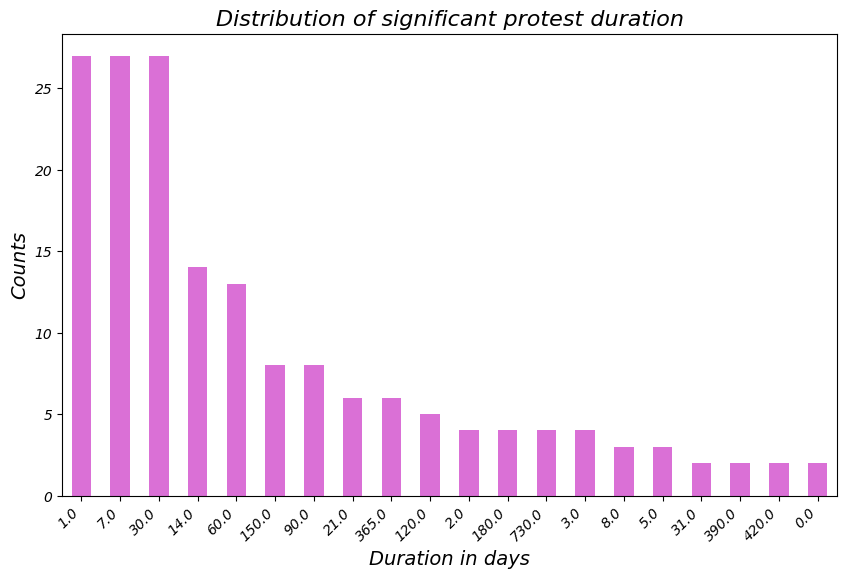

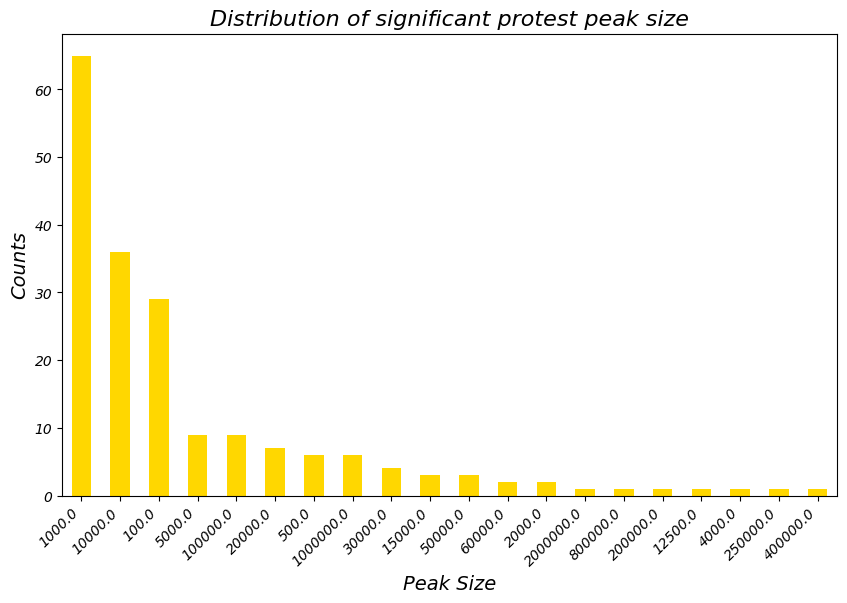

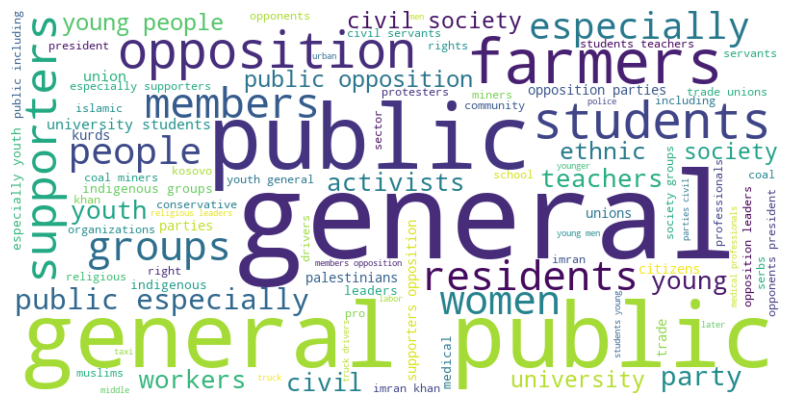

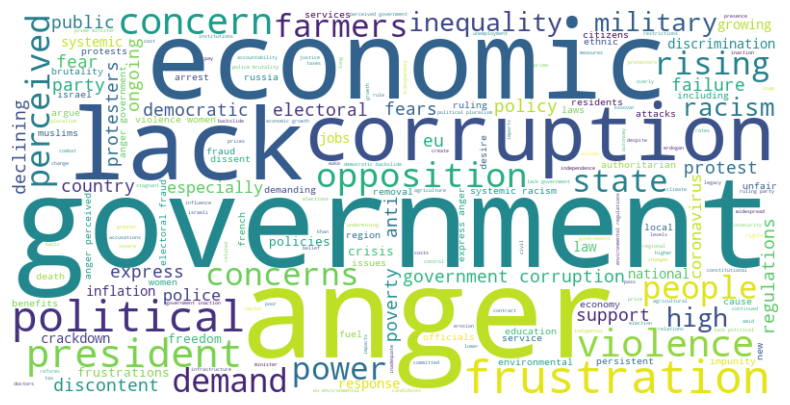

In [14]:
def plot_hist(data, title, xlabel, color_):
    plt.figure(figsize=(10, 6))  
    data.value_counts().head(20).plot(kind='bar', color=color_)
    plt.title(title, fontsize=16)
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel('Counts', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.show()  

plot_hist(significant['Duration in days'], 'Distribution of significant protest duration',
          'Duration in days', 'orchid')
plot_hist(significant['Peak Size'], 'Distribution of significant protest peak size',
          'Peak Size', 'gold')
word_cloud(significant,'Key Participants')
word_cloud(significant,'Motivations')

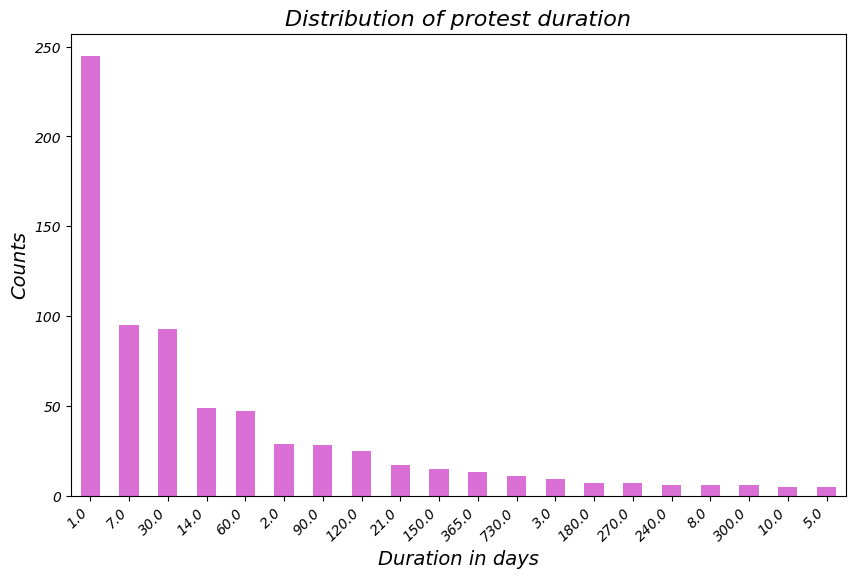

In [15]:
plot_hist(data['Duration in days'], 'Distribution of protest duration',
          'Duration in days', 'orchid')

In [16]:
data.columns

Index(['Country', 'Protest Name', 'Start Date', 'Freedom Rating (Status)',
       'Triggers', 'Motivations', 'Peak Size', 'Key Participants', 'Outcomes',
       'Active protests', 'Economic motivation?', 'Political motivation?',
       'Corruption motivation?', 'Gender motivation?', 'Size category',
       'Protests with a significant outcome',
       'Large protests (Over 100,000 protesting)',
       'Violent government response', 'Long protests (more than 3 months)',
       'Coronavirus-related protests', 'Capital city', 'Duration in days',
       'Free'],
      dtype='object')

In [17]:
# dropping 'Key Participants' column as it is redundant when adding the topic of the protest at a later stage
data.dropna(subset=['Outcomes'],inplace=True)
X = data.drop(columns = ['Country','Protest Name','Start Date','Freedom Rating (Status)','Triggers',
                         'Motivations','Key Participants', 'Outcomes','Size category',
                         'Capital city', 'Size category', 'Large protests (Over 100,000 protesting)'], axis=1)
X.isnull().sum()

Peak Size                              0
Active protests                        0
Economic motivation?                   0
Political motivation?                  0
Corruption motivation?                 0
Gender motivation?                     0
Protests with a significant outcome    0
Violent government response            0
Long protests (more than 3 months)     0
Coronavirus-related protests           0
Duration in days                       0
Free                                   0
dtype: int64

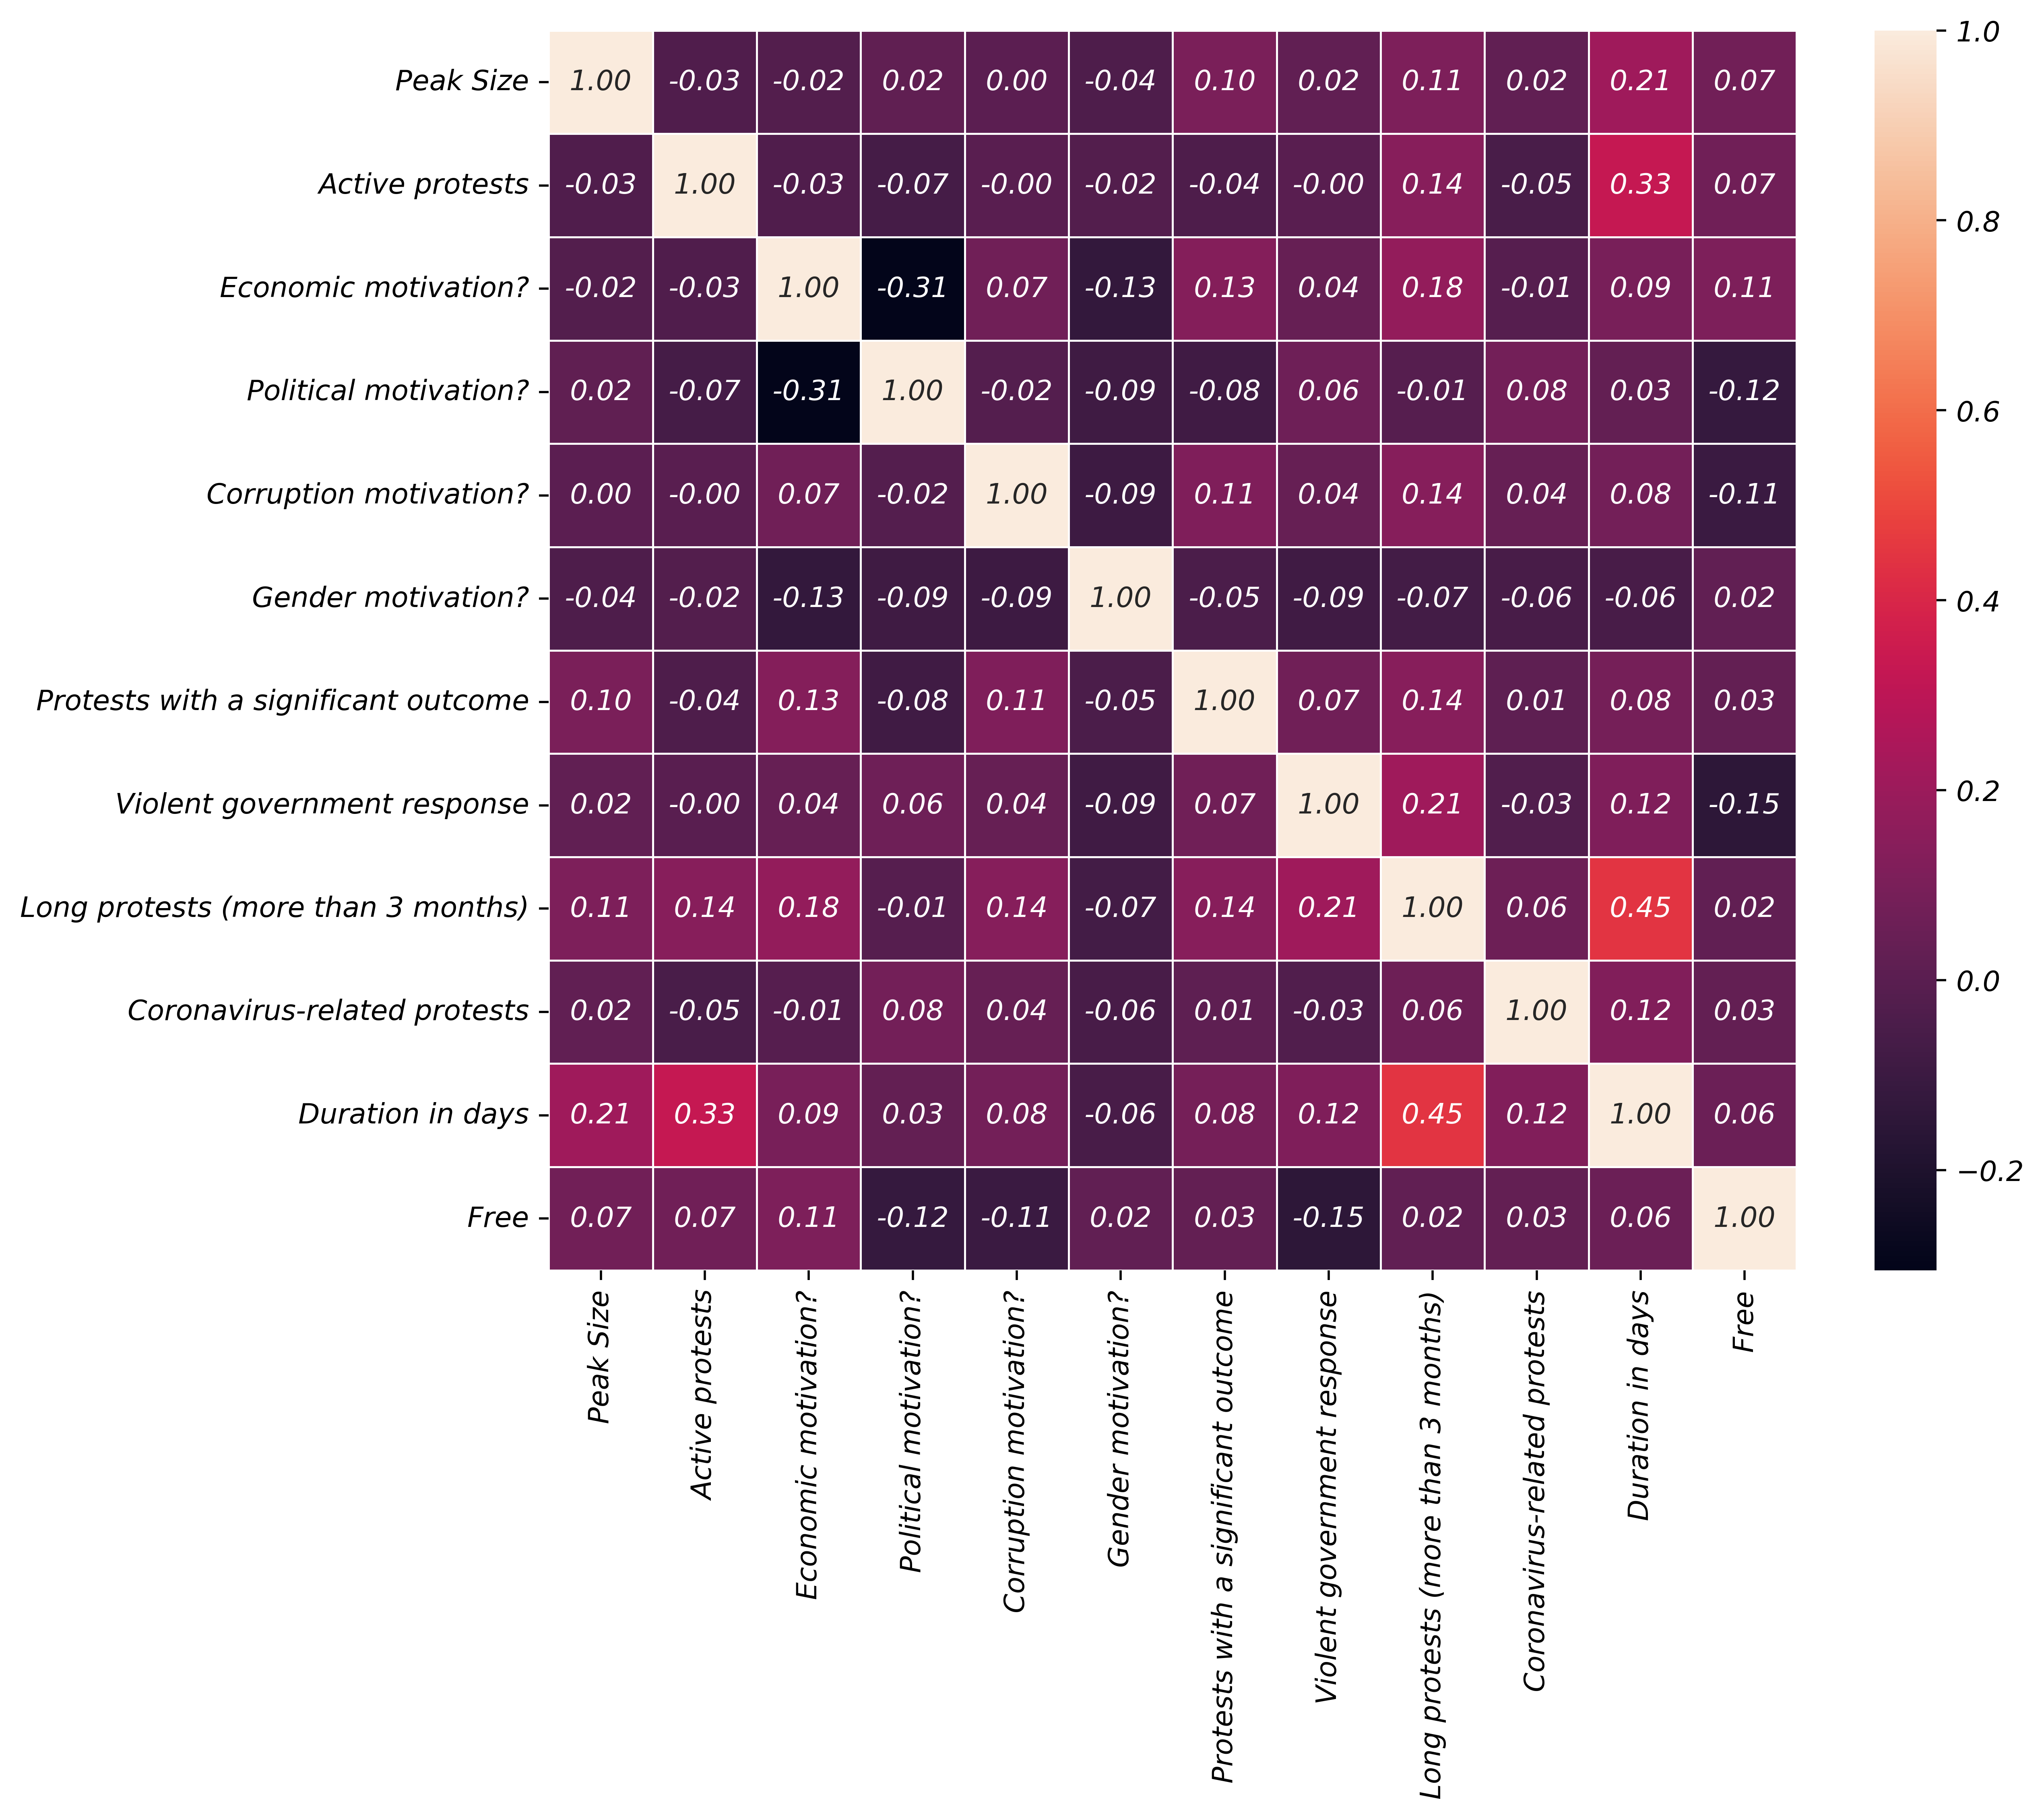

In [18]:
# Find the pearson correlations matrix
corr = X.corr(method = 'pearson')
plt.figure(figsize=(10,8), dpi =500)
sns.heatmap(corr,annot=True,fmt=".2f", linewidth=.5)
plt.show()

## Prediction - Part 1

In the first part, I will build a model predicting the 'significant outcome' feature. 

Normalizing values of non-binary columns

In [19]:
from sklearn.preprocessing import StandardScaler
 
columns_to_normalize = ['Peak Size', 'Duration in days']
scaler = StandardScaler()
X[columns_to_normalize] = scaler.fit_transform(X[columns_to_normalize])

In [20]:
X.dropna(subset=['Peak Size', 'Duration in days'],inplace=True)
X[['Peak Size', 'Duration in days']].isnull().sum()

Peak Size           0
Duration in days    0
dtype: int64

In [21]:
X[['Peak Size', 'Duration in days']]

,Peak Size,Duration in days
0,-0.214136,0.072707
1,-0.214136,-0.445327
2,-0.209100,-0.445327
3,-0.209100,-0.445327
4,-0.214136,-0.445327
...,...,...
800,-0.209100,-0.116682
801,0.344798,2.919112
802,-0.046847,-0.445327
803,0.904292,0.050426


In [22]:
y = X['Protests with a significant outcome']
X = X.drop(['Protests with a significant outcome'],axis=1)
X

,Peak Size,Active protests,Economic motivation?,Political motivation?,Corruption motivation?,Gender motivation?,Violent government response,Long protests (more than 3 months),Coronavirus-related protests,Duration in days,Free
0,-0.214136,1,0,1,0,0,0,0,0,0.072707,0
1,-0.214136,0,0,1,0,0,0,0,0,-0.445327,0
2,-0.209100,0,0,1,0,0,0,0,0,-0.445327,0
3,-0.209100,0,1,0,0,0,0,0,0,-0.445327,0
4,-0.214136,0,0,1,0,0,0,0,0,-0.445327,0
...,...,...,...,...,...,...,...,...,...,...,...
800,-0.209100,0,1,0,1,0,0,0,0,-0.116682,0
801,0.344798,0,1,1,1,0,0,0,0,2.919112,0
802,-0.046847,0,1,1,1,0,0,0,0,-0.445327,1
803,0.904292,0,0,1,0,0,0,0,0,0.050426,0


### Hyperparameter Tuning

In [23]:
# Importing the necessary libraries
from scipy.stats import randint
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint as sp_randint
import xgboost as xgb
import scipy.stats as stats

In [24]:
def hyperparameter_tuning(model_name, X, y):
    if model_name == 'dt':
        param_dist = {"max_depth": [3, None],
              "max_features": randint(1, 9),
              "min_samples_leaf": randint(1, 9),
              "criterion": ["gini", "entropy"]}

        tree = DecisionTreeClassifier()
        tree_cv = RandomizedSearchCV(tree, param_dist, cv=5)
        tree_cv.fit(X,y)
        print("Tuned Decision Tree Parameters: {}".format(tree_cv.best_params_))
        
    elif model_name == 'rf':
        clf = RandomForestClassifier(n_estimators=50)

        param_dist = {"max_depth": [3, None],
              "max_features": sp_randint(1, 11),
              "min_samples_split": sp_randint(2, 11),
              "min_samples_leaf": sp_randint(1, 11),
              "bootstrap": [True, False],
              "criterion": ["gini", "entropy"]}

        samples = 8  # number of random samples 
        randomCV = RandomizedSearchCV(clf, param_distributions=param_dist, n_iter=samples,cv=3)

        randomCV.fit(X, y)
        print(f'Tuned Random Forest Parameters: {randomCV.best_params_}')
        
    elif model_name == 'xgb':
        param_dist = {
    'max_depth': stats.randint(3, 15),
    'learning_rate': [0.05,0.10,0.15,0.20,0.25,0.30],
    'subsample': stats.uniform(0.5, 0.5),
    'min_child_weight' : [1,3,5,7],
    'gamma': [0.0,0.1,0.2,0.3,0.4],
    'n_estimators':stats.randint(50, 200),
    'colsample_bytree' : [0.3,0.4,0.5,0.7]}
        xgb_model = xgb.XGBClassifier()
        random_search = RandomizedSearchCV(xgb_model, param_distributions=param_dist, n_iter=10, cv=5, scoring='f1')
        random_search.fit(X, y)
        print(f'Tuned XGBoost parameters {random_search.best_params_}')

In [25]:
hyperparameter_tuning('dt',X,y)
hyperparameter_tuning('rf',X,y)
hyperparameter_tuning('xgb',X,y)

Tuned Decision Tree Parameters: {'criterion': 'gini', 'max_depth': 3, 'max_features': 2, 'min_samples_leaf': 2}
Tuned Random Forest Parameters: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': None, 'max_features': 2, 'min_samples_leaf': 9, 'min_samples_split': 6}
Tuned XGBoost parameters {'colsample_bytree': 0.4, 'gamma': 0.4, 'learning_rate': 0.3, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 163, 'subsample': 0.8426045823286329}


### Initalizing the models based on the best parameters

In [26]:
xgb_model = xgb.XGBClassifier(colsample_bytree=0.5, 
                                      gamma= 0.1, learning_rate= 0.3, 
                                      max_depth= 14, min_child_weight= 1, 
                                      n_estimators= 124, subsample= 0.8505331985188996)
        
rf_model = RandomForestClassifier(n_estimators=50, bootstrap=True, criterion='gini', max_depth=None, max_features=1,
                            min_samples_leaf=9, min_samples_split=9)

dt_model = DecisionTreeClassifier(criterion="entropy", max_depth=3, 
                               max_features=1,min_samples_leaf=7)

In [27]:
def prediction(X,y,test_size, shuffle_, model):
    # I do this to compare results for both cases: with shuffling and without 
    if shuffle_:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size) 
    else:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, shuffle=False)
        
    # Identify rows to duplicate based on the target variable
    rows_to_duplicate = X_train[y_train == 1]
    
    # Duplicate the rows in both X_train and y_train
    X_train = pd.concat([X_train, rows_to_duplicate, rows_to_duplicate], ignore_index=True)
    y_train = pd.concat([y_train, y_train[y_train == 1], y_train[y_train == 1]], ignore_index=True)
    
    # Looking at the distribution of the target variable after duplication
    print(f"For a test size of {test_size} the distribution of the target variable after duplication is:\n {y_train.value_counts()}")
        
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)
        
    # Get the feature importance scores
    feature_importance = model.feature_importances_
    importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importance})
    importance_df = importance_df.sort_values('Importance', ascending=False)
    print(importance_df)
        
    y_pred = pd.DataFrame(y_pred)
    y_test = np.array(y_test)
    return y_pred, y_test

def choose_threshold(y_pred_model,y_test):
    # Transforming the data frame of positive probabilities into an array for later operations
    y_pred_negative = y_pred_model[0]
    
    # Performing a Grid Search to determine the best threshold
    best_threshold = 0
    best_score = 0
    best_accuracy = 0
    
    for threshold in np.arange(0, 1, 0.01):
        y_pred_temp = (y_pred_negative < threshold).astype(int) # Goes through the whole array and returns 1 or 0 based on the threshold
        score = f1_score(y_test, y_pred_temp)
        if score > best_score:
            best_score = score
            best_accuracy = accuracy_score(y_test, y_pred_temp)
            best_threshold = threshold
            
    print(f"Best threshold: {best_threshold}, best f1-score: {best_score}, best accuracy: {best_accuracy}")
    return best_threshold


def evaluate(y_pred, best_threshold, y_test):
    # Taking only the predictions for the label '1' (as it is the same as '0' but substracting 1)
    if len(y_pred.columns) > 1:
        predictions = y_pred[1]
    else:
        predictions = y_pred
    # Getting predictions based on the best threshold
    y_pred_binary = np.where(predictions >= (1 - best_threshold), 1, 0)
    
    # Evaluation
    accuracy = accuracy_score(y_test, y_pred_binary)
    precision = precision_score(y_test, y_pred_binary)
    recall = recall_score(y_test, y_pred_binary)
    f1 = f1_score(y_test, y_pred_binary)
    
    results = {'Accuracy': accuracy,
               'Precision': precision,
               'Recall': recall,
               'f1': f1}
    
    return y_pred_binary, results

def create_confusion_matrix(y_test, y_pred_binary):
    cm = confusion_matrix(y_test, y_pred_binary)

    # Plotting the confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 16})  # Increase font size here

    # Adding labels to the confusion matrix squares
    class_names = ['Negative', 'Positive']
    tick_marks = [0.5, 1.5]
    plt.xticks(tick_marks, class_names, fontsize=14)  # Adjust font size for x-axis labels
    plt.yticks(tick_marks, class_names, fontsize=14)  # Adjust font size for y-axis labels
    plt.xlabel('Predicted', fontsize=14)  # Adjust font size for x-axis title
    plt.ylabel('Actual', fontsize=14)  # Adjust font size for y-axis title
    plt.title('Confusion Matrix', fontsize=16)  # Adjust font size for the title

    # Show the plot
    plt.show()

In [28]:
# Creating dictionaries to save the results
xgb_dict = {'0.4_Shuffle_True':[],'0.3_Shuffle_True':[],'0.2_Shuffle_True':[],'0.4_Shuffle_False':[],'0.3_Shuffle_False':[],'0.2_Shuffle_False':[]}
dt_dict= {'0.4_Shuffle_True':[],'0.3_Shuffle_True':[],'0.2_Shuffle_True':[],'0.4_Shuffle_False':[],'0.3_Shuffle_False':[],'0.2_Shuffle_False':[]}
rf_dict = {'0.4_Shuffle_True':[],'0.3_Shuffle_True':[],'0.2_Shuffle_True':[],'0.4_Shuffle_False':[],'0.3_Shuffle_False':[],'0.2_Shuffle_False':[]}

best_model = ''
best_f1_score = 0
best_accuracy = 0
best_precision = 0
best_recall = 0

def assess_best_model(results, model_param, best_f1_score, best_accuracy, best_precision, best_recall, best_model):
    if results['Precision'] > best_accuracy:
        best_f1_score = results['f1']
        best_model = model_param
        best_accuracy = results['Accuracy']
        best_precision = results['Precision']
        best_recall = results['Recall']
    return best_f1_score, best_accuracy, best_precision, best_recall, best_model

### Test size = 0.4

First model - XGBoost

In [29]:
y_pred_xgb_40_False, y_test_xgb_40_False = prediction(X,y,0.4,False,xgb_model)
best_threshold_xgb = choose_threshold(y_pred_xgb_40_False, y_test_xgb_40_False)
y_pred_binary_xgb_40_False, results = evaluate(y_pred_xgb_40_False, best_threshold_xgb, y_test_xgb_40_False)
xgb_dict['0.4_Shuffle_False'].append(results)
best_f1_score, best_accuracy, best_precision, best_recall, best_model = assess_best_model(results,'xgb_40_False',best_f1_score, best_accuracy, best_precision, best_recall, best_model)

For a test size of 0.4 the distribution of the target variable after duplication is:
 Protests with a significant outcome
0    387
1    285
Name: count, dtype: int64
                               Feature  Importance
9                     Duration in days    0.136738
0                            Peak Size    0.119074
2                 Economic motivation?    0.117630
6          Violent government response    0.111222
4               Corruption motivation?    0.095145
10                                Free    0.093487
5                   Gender motivation?    0.086513
1                      Active protests    0.081144
3                Political motivation?    0.080902
7   Long protests (more than 3 months)    0.078145
8         Coronavirus-related protests    0.000000
Best threshold: 0.99, best f1-score: 0.4671532846715329, best accuracy: 0.3198757763975155


Second model: Decision Tree

In [30]:
y_pred_dt_40_False, y_test_dt_40_False = prediction(X,y,0.4,False,dt_model)
best_threshold_dt = choose_threshold(y_pred_dt_40_False, y_test_dt_40_False)
y_pred_binary_dt_40_False, results = evaluate(y_pred_dt_40_False, best_threshold_dt, y_test_dt_40_False)
dt_dict['0.4_Shuffle_False'].append(results)
best_f1_score, best_accuracy, best_precision, best_recall, best_model = assess_best_model(results,'dt_40_False',best_f1_score, best_accuracy, best_precision, best_recall, best_model)

For a test size of 0.4 the distribution of the target variable after duplication is:
 Protests with a significant outcome
0    387
1    285
Name: count, dtype: int64
                               Feature  Importance
9                     Duration in days    0.571650
0                            Peak Size    0.208502
10                                Free    0.091984
3                Political motivation?    0.079317
7   Long protests (more than 3 months)    0.048547
1                      Active protests    0.000000
2                 Economic motivation?    0.000000
4               Corruption motivation?    0.000000
5                   Gender motivation?    0.000000
6          Violent government response    0.000000
8         Coronavirus-related protests    0.000000
Best threshold: 0.65, best f1-score: 0.4661246612466124, best accuracy: 0.38819875776397517


Third model: Random Forest

In [31]:
y_pred_rf_40_False, y_test_rf_40_False = prediction(X,y,0.4,False,rf_model)
best_threshold_rf = choose_threshold(y_pred_rf_40_False, y_test_rf_40_False)
y_pred_binary_rf_40_False, results = evaluate(y_pred_rf_40_False, best_threshold_rf, y_test_rf_40_False)
rf_dict['0.4_Shuffle_False'].append(results)
best_f1_score, best_accuracy, best_precision, best_recall, best_model = assess_best_model(results,'rf_40_False',best_f1_score, best_accuracy, best_precision, best_recall, best_model)

For a test size of 0.4 the distribution of the target variable after duplication is:
 Protests with a significant outcome
0    387
1    285
Name: count, dtype: int64
                               Feature  Importance
9                     Duration in days    0.369185
2                 Economic motivation?    0.153515
0                            Peak Size    0.129839
7   Long protests (more than 3 months)    0.086937
6          Violent government response    0.064635
10                                Free    0.062945
4               Corruption motivation?    0.044742
3                Political motivation?    0.042663
5                   Gender motivation?    0.030377
1                      Active protests    0.015161
8         Coronavirus-related protests    0.000000
Best threshold: 0.6, best f1-score: 0.5174418604651163, best accuracy: 0.484472049689441


### Test size = 0.3

In [32]:
y_pred_xgb_30_False, y_test_xgb_30_False = prediction(X,y,0.3,False,xgb_model)
best_threshold_xgb = choose_threshold(y_pred_xgb_30_False, y_test_xgb_30_False)
y_pred_binary_xgb_30_False, results = evaluate(y_pred_xgb_30_False, best_threshold_xgb, y_test_xgb_30_False)
xgb_dict['0.3_Shuffle_False'].append(results)
best_f1_score, best_accuracy, best_precision, best_recall, best_model = assess_best_model(results,'xgb_30_False',best_f1_score, best_accuracy, best_precision, best_recall, best_model)

For a test size of 0.3 the distribution of the target variable after duplication is:
 Protests with a significant outcome
0    452
1    330
Name: count, dtype: int64
                               Feature  Importance
9                     Duration in days    0.121721
8         Coronavirus-related protests    0.108868
3                Political motivation?    0.103038
7   Long protests (more than 3 months)    0.095121
0                            Peak Size    0.092378
6          Violent government response    0.088156
5                   Gender motivation?    0.086102
2                 Economic motivation?    0.082254
10                                Free    0.075693
4               Corruption motivation?    0.075046
1                      Active protests    0.071623
Best threshold: 0.98, best f1-score: 0.48829431438127086, best accuracy: 0.3677685950413223


In [33]:
y_pred_dt_30_False, y_test_dt_30_False = prediction(X,y,0.3,False,dt_model)
best_threshold_dt = choose_threshold(y_pred_dt_30_False, y_test_dt_30_False)
y_pred_binary_dt_30_False, results = evaluate(y_pred_dt_30_False, best_threshold_dt, y_test_dt_30_False)
dt_dict['0.3_Shuffle_False'].append(results)
best_f1_score, best_accuracy, best_precision, best_recall, best_model = assess_best_model(results,'dt_30_False',best_f1_score, best_accuracy, best_precision, best_recall, best_model)

For a test size of 0.3 the distribution of the target variable after duplication is:
 Protests with a significant outcome
0    452
1    330
Name: count, dtype: int64
                               Feature  Importance
9                     Duration in days    0.560167
2                 Economic motivation?    0.237773
10                                Free    0.083265
3                Political motivation?    0.046343
5                   Gender motivation?    0.040591
1                      Active protests    0.031861
0                            Peak Size    0.000000
4               Corruption motivation?    0.000000
6          Violent government response    0.000000
7   Long protests (more than 3 months)    0.000000
8         Coronavirus-related protests    0.000000
Best threshold: 0.61, best f1-score: 0.509933774834437, best accuracy: 0.3884297520661157


In [34]:
y_pred_rf_30_False, y_test_rf_30_False = prediction(X,y,0.3,False,rf_model)
best_threshold_rf = choose_threshold(y_pred_rf_30_False, y_test_rf_30_False)
y_pred_binary_rf_30_False, results = evaluate(y_pred_rf_30_False, best_threshold_rf, y_test_rf_30_False)
rf_dict['0.3_Shuffle_False'].append(results)
best_f1_score, best_accuracy, best_precision, best_recall, best_model = assess_best_model(results,'rf_30_False',best_f1_score, best_accuracy, best_precision, best_recall, best_model)

For a test size of 0.3 the distribution of the target variable after duplication is:
 Protests with a significant outcome
0    452
1    330
Name: count, dtype: int64
                               Feature  Importance
9                     Duration in days    0.382669
0                            Peak Size    0.142733
2                 Economic motivation?    0.125704
7   Long protests (more than 3 months)    0.076259
6          Violent government response    0.068439
10                                Free    0.068334
3                Political motivation?    0.044638
8         Coronavirus-related protests    0.031327
1                      Active protests    0.022622
5                   Gender motivation?    0.019260
4               Corruption motivation?    0.018015
Best threshold: 0.67, best f1-score: 0.525974025974026, best accuracy: 0.39669421487603307


### Test size = 0.2

In [35]:
y_pred_xgb_20_False, y_test_xgb_20_False = prediction(X,y,0.2,False,xgb_model)
best_threshold_xgb = choose_threshold(y_pred_xgb_20_False, y_test_xgb_20_False)
y_pred_binary_xgb_20_False, results = evaluate(y_pred_xgb_20_False, best_threshold_xgb, y_test_xgb_20_False)
xgb_dict['0.2_Shuffle_False'].append(results)
best_f1_score, best_accuracy, best_precision, best_recall, best_model = assess_best_model(results,'xgb_20_False',best_f1_score, best_accuracy, best_precision, best_recall, best_model)

For a test size of 0.2 the distribution of the target variable after duplication is:
 Protests with a significant outcome
0    511
1    396
Name: count, dtype: int64
                               Feature  Importance
9                     Duration in days    0.123273
8         Coronavirus-related protests    0.101084
0                            Peak Size    0.099543
2                 Economic motivation?    0.096110
4               Corruption motivation?    0.090457
6          Violent government response    0.088686
7   Long protests (more than 3 months)    0.084003
10                                Free    0.083957
1                      Active protests    0.081387
3                Political motivation?    0.079540
5                   Gender motivation?    0.071960
Best threshold: 0.99, best f1-score: 0.5395348837209303, best accuracy: 0.38509316770186336


In [36]:
y_pred_dt_20_False, y_test_dt_20_False = prediction(X,y,0.3,False,dt_model)
best_threshold_dt = choose_threshold(y_pred_dt_20_False, y_test_dt_20_False)
y_pred_binary_dt_20_False, results = evaluate(y_pred_dt_20_False, best_threshold_dt, y_test_dt_20_False)
dt_dict['0.2_Shuffle_False'].append(results)
best_f1_score, best_accuracy, best_precision, best_recall, best_model = assess_best_model(results,'dt_20_False',best_f1_score, best_accuracy, best_precision, best_recall, best_model)

For a test size of 0.3 the distribution of the target variable after duplication is:
 Protests with a significant outcome
0    452
1    330
Name: count, dtype: int64
                               Feature  Importance
7   Long protests (more than 3 months)    0.623632
1                      Active protests    0.179504
5                   Gender motivation?    0.120073
2                 Economic motivation?    0.076791
0                            Peak Size    0.000000
3                Political motivation?    0.000000
4               Corruption motivation?    0.000000
6          Violent government response    0.000000
8         Coronavirus-related protests    0.000000
9                     Duration in days    0.000000
10                                Free    0.000000
Best threshold: 0.72, best f1-score: 0.5061728395061729, best accuracy: 0.33884297520661155


In [37]:
y_pred_rf_20_False, y_test_rf_20_False = prediction(X,y,0.3,False,rf_model)
best_threshold_rf = choose_threshold(y_pred_rf_20_False, y_test_rf_20_False)
y_pred_binary_rf_20_False, results = evaluate(y_pred_rf_20_False, best_threshold_rf, y_test_rf_20_False)
rf_dict['0.2_Shuffle_False'].append(results)
best_f1_score, best_accuracy, best_precision, best_recall, best_model = assess_best_model(results,'rf_20_False',best_f1_score, best_accuracy, best_precision, best_recall, best_model)

For a test size of 0.3 the distribution of the target variable after duplication is:
 Protests with a significant outcome
0    452
1    330
Name: count, dtype: int64
                               Feature  Importance
9                     Duration in days    0.368940
0                            Peak Size    0.165292
2                 Economic motivation?    0.149405
7   Long protests (more than 3 months)    0.094474
10                                Free    0.055694
3                Political motivation?    0.052704
6          Violent government response    0.047308
4               Corruption motivation?    0.028818
5                   Gender motivation?    0.014019
1                      Active protests    0.013126
8         Coronavirus-related protests    0.010220
Best threshold: 0.61, best f1-score: 0.5371024734982333, best accuracy: 0.45867768595041325


### Shuffle = True

In [38]:
y_pred_xgb_40_True, y_test_xgb_40_True = prediction(X,y,0.4,True,xgb_model)
best_threshold_xgb = choose_threshold(y_pred_xgb_40_True, y_test_xgb_40_True)
y_pred_binary_xgb_40_True, results = evaluate(y_pred_xgb_40_True, best_threshold_xgb, y_test_xgb_40_True)
xgb_dict['0.4_Shuffle_True'].append(results)
best_f1_score, best_accuracy, best_precision, best_recall, best_model = assess_best_model(results,'xgb_40_True',best_f1_score, best_accuracy, best_precision, best_recall, best_model)

For a test size of 0.4 the distribution of the target variable after duplication is:
 Protests with a significant outcome
0    368
1    342
Name: count, dtype: int64


                               Feature  Importance
9                     Duration in days    0.134228
7   Long protests (more than 3 months)    0.107364
10                                Free    0.102926
6          Violent government response    0.098750
0                            Peak Size    0.098589
5                   Gender motivation?    0.086572
3                Political motivation?    0.083589
1                      Active protests    0.079449
4               Corruption motivation?    0.075720
2                 Economic motivation?    0.071426
8         Coronavirus-related protests    0.061389
Best threshold: 0.97, best f1-score: 0.38011695906432746, best accuracy: 0.3416149068322981


In [39]:
y_pred_dt_40_True, y_test_dt_40_True = prediction(X,y,0.4,True,dt_model)
best_threshold_dt = choose_threshold(y_pred_dt_40_True, y_test_dt_40_True)
y_pred_binary_dt_40_True, results = evaluate(y_pred_dt_40_True, best_threshold_dt, y_test_dt_40_True)
dt_dict['0.4_Shuffle_True'].append(results)
best_f1_score, best_accuracy, best_precision, best_recall, best_model = assess_best_model(results,'dt_40_True',best_f1_score, best_accuracy, best_precision, best_recall, best_model)

For a test size of 0.4 the distribution of the target variable after duplication is:
 Protests with a significant outcome
0    366
1    348
Name: count, dtype: int64
                               Feature  Importance
9                     Duration in days    0.854832
0                            Peak Size    0.125918
4               Corruption motivation?    0.019250
1                      Active protests    0.000000
2                 Economic motivation?    0.000000
3                Political motivation?    0.000000
5                   Gender motivation?    0.000000
6          Violent government response    0.000000
7   Long protests (more than 3 months)    0.000000
8         Coronavirus-related protests    0.000000
10                                Free    0.000000
Best threshold: 0.5, best f1-score: 0.43448275862068964, best accuracy: 0.4906832298136646


In [40]:
y_pred_rf_40_True, y_test_rf_40_True = prediction(X,y,0.4,True,rf_model)
best_threshold_rf = choose_threshold(y_pred_rf_40_True, y_test_rf_40_True)
y_pred_binary_rf_40_True, results = evaluate(y_pred_rf_40_True, best_threshold_rf, y_test_rf_40_True)
rf_dict['0.4_Shuffle_True'].append(results)
best_f1_score, best_accuracy, best_precision, best_recall, best_model = assess_best_model(results,'rf_40_True',best_f1_score, best_accuracy, best_precision, best_recall, best_model)

For a test size of 0.4 the distribution of the target variable after duplication is:
 Protests with a significant outcome
1    375
0    357
Name: count, dtype: int64
                               Feature  Importance
9                     Duration in days    0.388423
0                            Peak Size    0.194556
2                 Economic motivation?    0.123776
3                Political motivation?    0.068150
7   Long protests (more than 3 months)    0.064323
6          Violent government response    0.054816
4               Corruption motivation?    0.049058
10                                Free    0.027789
8         Coronavirus-related protests    0.018716
5                   Gender motivation?    0.006825
1                      Active protests    0.003568
Best threshold: 0.46, best f1-score: 0.44324324324324327, best accuracy: 0.6801242236024845


In [41]:
y_pred_xgb_30_True, y_test_xgb_30_True = prediction(X,y,0.3,True,xgb_model)
best_threshold_xgb = choose_threshold(y_pred_xgb_30_True, y_test_xgb_30_True)
y_pred_binary_xgb_30_True, results = evaluate(y_pred_xgb_30_True, best_threshold_xgb, y_test_xgb_30_True)
xgb_dict['0.3_Shuffle_True'].append(results)
best_f1_score, best_accuracy, best_precision, best_recall, best_model = assess_best_model(results,'xgb_30_True',best_f1_score, best_accuracy, best_precision, best_recall, best_model)

For a test size of 0.3 the distribution of the target variable after duplication is:
 Protests with a significant outcome
1    426
0    420
Name: count, dtype: int64


                               Feature  Importance
9                     Duration in days    0.125144
7   Long protests (more than 3 months)    0.106412
0                            Peak Size    0.099242
6          Violent government response    0.095035
1                      Active protests    0.091669
2                 Economic motivation?    0.087939
10                                Free    0.087690
3                Political motivation?    0.087566
4               Corruption motivation?    0.082482
8         Coronavirus-related protests    0.070840
5                   Gender motivation?    0.065981
Best threshold: 0.99, best f1-score: 0.35211267605633806, best accuracy: 0.2396694214876033


In [42]:
y_pred_dt_30_True, y_test_dt_30_True = prediction(X,y,0.3,True,dt_model)
best_threshold_dt = choose_threshold(y_pred_dt_30_True, y_test_dt_30_True)
y_pred_binary_dt_30_True, results = evaluate(y_pred_dt_30_True, best_threshold_dt, y_test_dt_30_True)
dt_dict['0.3_Shuffle_True'].append(results)
best_f1_score, best_accuracy, best_precision, best_recall, best_model = assess_best_model(results,'dt_30_True',best_f1_score, best_accuracy, best_precision, best_recall, best_model)

For a test size of 0.3 the distribution of the target variable after duplication is:
 Protests with a significant outcome
0    436
1    378
Name: count, dtype: int64
                               Feature  Importance
9                     Duration in days    0.798728
0                            Peak Size    0.132947
6          Violent government response    0.043153
1                      Active protests    0.025172
2                 Economic motivation?    0.000000
3                Political motivation?    0.000000
4               Corruption motivation?    0.000000
5                   Gender motivation?    0.000000
7   Long protests (more than 3 months)    0.000000
8         Coronavirus-related protests    0.000000
10                                Free    0.000000
Best threshold: 0.47000000000000003, best f1-score: 0.5022831050228311, best accuracy: 0.5495867768595041


In [43]:
y_pred_rf_30_True, y_test_rf_30_True = prediction(X,y,0.3,True,rf_model)
best_threshold_rf = choose_threshold(y_pred_rf_30_True, y_test_rf_30_True)
y_pred_binary_rf_30_True, results = evaluate(y_pred_rf_30_True, best_threshold_rf, y_test_rf_30_True)
rf_dict['0.3_Shuffle_True'].append(results)
best_f1_score, best_accuracy, best_precision, best_recall, best_model = assess_best_model(results,'rf_30_True',best_f1_score, best_accuracy, best_precision, best_recall, best_model)

For a test size of 0.3 the distribution of the target variable after duplication is:
 Protests with a significant outcome
0    431
1    393
Name: count, dtype: int64
                               Feature  Importance
9                     Duration in days    0.348580
0                            Peak Size    0.178041
2                 Economic motivation?    0.128837
7   Long protests (more than 3 months)    0.108147
3                Political motivation?    0.069682
4               Corruption motivation?    0.050999
10                                Free    0.050572
6          Violent government response    0.035856
8         Coronavirus-related protests    0.016547
5                   Gender motivation?    0.006599
1                      Active protests    0.006140
Best threshold: 0.54, best f1-score: 0.47904191616766467, best accuracy: 0.640495867768595


In [44]:
y_pred_xgb_20_True, y_test_xgb_20_True = prediction(X,y,0.2,True,xgb_model)
best_threshold_xgb = choose_threshold(y_pred_xgb_20_True, y_test_xgb_20_True)
y_pred_binary_xgb_20_True, results = evaluate(y_pred_xgb_20_True, best_threshold_xgb, y_test_xgb_20_True)
xgb_dict['0.2_Shuffle_True'].append(results)
best_f1_score, best_accuracy, best_precision, best_recall, best_model = assess_best_model(results,'xgb_20_True',best_f1_score, best_accuracy, best_precision, best_recall, best_model)

For a test size of 0.2 the distribution of the target variable after duplication is:
 Protests with a significant outcome
0    496
1    441
Name: count, dtype: int64


                               Feature  Importance
7   Long protests (more than 3 months)    0.120272
9                     Duration in days    0.118126
0                            Peak Size    0.091529
8         Coronavirus-related protests    0.088757
6          Violent government response    0.087205
2                 Economic motivation?    0.086422
10                                Free    0.085910
4               Corruption motivation?    0.084550
3                Political motivation?    0.083268
1                      Active protests    0.078760
5                   Gender motivation?    0.075202
Best threshold: 0.75, best f1-score: 0.46875000000000006, best accuracy: 0.577639751552795


In [45]:
y_pred_dt_20_True, y_test_dt_20_True = prediction(X,y,0.2,True,dt_model)
best_threshold_dt = choose_threshold(y_pred_dt_20_True, y_test_dt_20_True)
y_pred_binary_dt_20_True, results = evaluate(y_pred_dt_20_True, best_threshold_dt, y_test_dt_20_True)
dt_dict['0.2_Shuffle_True'].append(results)
best_f1_score, best_accuracy, best_precision, best_recall, best_model = assess_best_model(results,'dt_20_True',best_f1_score, best_accuracy, best_precision, best_recall, best_model)

For a test size of 0.2 the distribution of the target variable after duplication is:
 Protests with a significant outcome
0    498
1    435
Name: count, dtype: int64
                               Feature  Importance
2                 Economic motivation?    0.531570
7   Long protests (more than 3 months)    0.300478
4               Corruption motivation?    0.129290
3                Political motivation?    0.037933
6          Violent government response    0.000729
0                            Peak Size    0.000000
1                      Active protests    0.000000
5                   Gender motivation?    0.000000
8         Coronavirus-related protests    0.000000
9                     Duration in days    0.000000
10                                Free    0.000000
Best threshold: 0.63, best f1-score: 0.4519230769230769, best accuracy: 0.2919254658385093


In [46]:
y_pred_rf_20_True, y_test_rf_20_True = prediction(X,y,0.2,True,rf_model)
best_threshold_rf = choose_threshold(y_pred_rf_20_True, y_test_rf_20_True)
y_pred_binary_mlp_20_True, results = evaluate(y_pred_rf_20_True, best_threshold_rf, y_test_rf_20_True)
rf_dict['0.2_Shuffle_True'].append(results)
best_f1_score, best_accuracy, best_precision, best_recall, best_model = assess_best_model(results,'rf_20_True',best_f1_score, best_accuracy, best_precision, best_recall, best_model)

For a test size of 0.2 the distribution of the target variable after duplication is:
 Protests with a significant outcome
0    488
1    465
Name: count, dtype: int64
                               Feature  Importance
9                     Duration in days    0.296320
0                            Peak Size    0.246079
2                 Economic motivation?    0.124004
7   Long protests (more than 3 months)    0.119383
4               Corruption motivation?    0.062130
3                Political motivation?    0.056018
6          Violent government response    0.037902
10                                Free    0.021887
5                   Gender motivation?    0.018560
8         Coronavirus-related protests    0.013449
1                      Active protests    0.004268
Best threshold: 0.54, best f1-score: 0.49541284403669716, best accuracy: 0.6583850931677019


### Best model

In [47]:
print(f'Best f1-score: {best_f1_score}, accuracy: {best_accuracy}, precision: {best_precision}, recall: {best_recall} for the best model parameters: {best_model}.')

Best f1-score: 0.5174418604651163, accuracy: 0.484472049689441, precision: 0.3603238866396761, recall: 0.9175257731958762 for the best model parameters: rf_40_False.


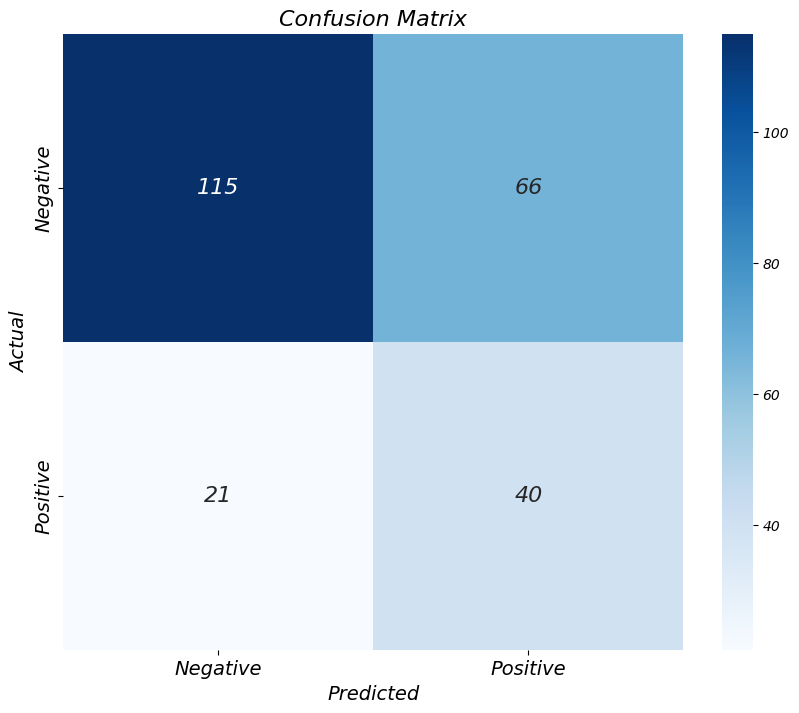

In [48]:
create_confusion_matrix(y_test_rf_30_True,y_pred_binary_rf_30_True)

In [49]:
xgb_dict

{'0.4_Shuffle_True': [{'Accuracy': 0.3416149068322981,
   'Precision': 0.24621212121212122,
   'Recall': 0.8333333333333334,
   'f1': 0.38011695906432746}],
 '0.3_Shuffle_True': [{'Accuracy': 0.2396694214876033,
   'Precision': 0.21367521367521367,
   'Recall': 1.0,
   'f1': 0.35211267605633806}],
 '0.2_Shuffle_True': [{'Accuracy': 0.577639751552795,
   'Precision': 0.3614457831325301,
   'Recall': 0.6666666666666666,
   'f1': 0.46875000000000006}],
 '0.4_Shuffle_False': [{'Accuracy': 0.3198757763975155,
   'Precision': 0.3057324840764331,
   'Recall': 0.9896907216494846,
   'f1': 0.4671532846715329}],
 '0.3_Shuffle_False': [{'Accuracy': 0.3677685950413223,
   'Precision': 0.33640552995391704,
   'Recall': 0.8902439024390244,
   'f1': 0.48829431438127086}],
 '0.2_Shuffle_False': [{'Accuracy': 0.38509316770186336,
   'Precision': 0.3741935483870968,
   'Recall': 0.9666666666666667,
   'f1': 0.5395348837209303}]}

In [50]:
rf_dict

{'0.4_Shuffle_True': [{'Accuracy': 0.6801242236024845,
   'Precision': 0.3474576271186441,
   'Recall': 0.6119402985074627,
   'f1': 0.44324324324324327}],
 '0.3_Shuffle_True': [{'Accuracy': 0.640495867768595,
   'Precision': 0.37735849056603776,
   'Recall': 0.6557377049180327,
   'f1': 0.47904191616766467}],
 '0.2_Shuffle_True': [{'Accuracy': 0.6583850931677019,
   'Precision': 0.375,
   'Recall': 0.7297297297297297,
   'f1': 0.49541284403669716}],
 '0.4_Shuffle_False': [{'Accuracy': 0.484472049689441,
   'Precision': 0.3603238866396761,
   'Recall': 0.9175257731958762,
   'f1': 0.5174418604651163}],
 '0.3_Shuffle_False': [{'Accuracy': 0.39669421487603307,
   'Precision': 0.3584070796460177,
   'Recall': 0.9878048780487805,
   'f1': 0.525974025974026}],
 '0.2_Shuffle_False': [{'Accuracy': 0.45867768595041325,
   'Precision': 0.3781094527363184,
   'Recall': 0.926829268292683,
   'f1': 0.5371024734982333}]}

In [51]:
dt_dict

{'0.4_Shuffle_True': [{'Accuracy': 0.4906832298136646,
   'Precision': 0.29439252336448596,
   'Recall': 0.8289473684210527,
   'f1': 0.43448275862068964}],
 '0.3_Shuffle_True': [{'Accuracy': 0.5495867768595041,
   'Precision': 0.35947712418300654,
   'Recall': 0.8333333333333334,
   'f1': 0.5022831050228311}],
 '0.2_Shuffle_True': [{'Accuracy': 0.2919254658385093,
   'Precision': 0.2919254658385093,
   'Recall': 1.0,
   'f1': 0.4519230769230769}],
 '0.4_Shuffle_False': [{'Accuracy': 0.38819875776397517,
   'Precision': 0.3161764705882353,
   'Recall': 0.8865979381443299,
   'f1': 0.4661246612466124}],
 '0.3_Shuffle_False': [{'Accuracy': 0.3884297520661157,
   'Precision': 0.35,
   'Recall': 0.9390243902439024,
   'f1': 0.509933774834437}],
 '0.2_Shuffle_False': [{'Accuracy': 0.33884297520661155,
   'Precision': 0.33884297520661155,
   'Recall': 1.0,
   'f1': 0.5061728395061729}]}

### Performing K-Fold Cross-Validation

In [52]:
from sklearn.model_selection import KFold
from openpyxl import Workbook
from sklearn.datasets import make_classification

# Initialize the k-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Random forest model
# the number of estimators really made a difference here 
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Initialize the DataFrame to collect results
comparison_df = pd.DataFrame()

# K-fold cross-validation
fold = 1
for train_index, test_index in kf.split(X):
    # Split the data
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Get predicted probabilities for the positive class on the training data
    y_pred_proba_train = model.predict_proba(X_train)[:, 1]
    
    # Collect predictions and actual values for the training data
    fold_df = pd.DataFrame({
        'Index': train_index,
        f'Fold_{fold}_Pred': y_pred_proba_train,
        f'Fold_{fold}_Actual': y_train.values
    })
    
    # Merge results from each fold into the main DataFrame
    if comparison_df.empty:
        comparison_df = fold_df
    else:
        comparison_df = pd.concat([comparison_df, fold_df], ignore_index=True)
    
    fold += 1

# Sort results by index for consistency
comparison_df = comparison_df.sort_values('Index').reset_index(drop=True)

# Save the results to an Excel file
comparison_df.to_excel('training_predictions_kfold.xlsx', index=False)

print("Results saved to 'training_predictions_kfold.xlsx'.")

Results saved to 'training_predictions_kfold.xlsx'.


In [53]:
len(X)

804

There were 804 data points before removing the outliers.

In [ ]:
indexes_to_drop = [11, 12, 30, 66, 70, 71, 74, 101, 136, 143, 225, 
                   228, 268, 273, 285, 286, 296, 302, 303, 307, 
                   333, 347, 366, 368, 369, 408, 429, 441, 457, 
                   462, 585, 588, 601, 641, 693, 713]
cleaned_X = X.copy()
# Drop rows by index and modify the original DataFrame
cleaned_X.drop(indexes_to_drop, inplace=True)
data.drop(indexes_to_drop, inplace=True)

In [55]:
cleaned_y = y.copy()
cleaned_y.drop(indexes_to_drop, inplace=True)

### Performing hyper-parameter tuning once again

In [56]:
hyperparameter_tuning('dt',cleaned_X, cleaned_y)
hyperparameter_tuning('rf',cleaned_X, cleaned_y)
hyperparameter_tuning('xgb',cleaned_X, cleaned_y)

Tuned Decision Tree Parameters: {'criterion': 'gini', 'max_depth': 3, 'max_features': 1, 'min_samples_leaf': 7}
Tuned Random Forest Parameters: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 3, 'max_features': 4, 'min_samples_leaf': 10, 'min_samples_split': 6}
Tuned XGBoost parameters {'colsample_bytree': 0.7, 'gamma': 0.0, 'learning_rate': 0.3, 'max_depth': 11, 'min_child_weight': 5, 'n_estimators': 108, 'subsample': 0.8081529237435197}


In [57]:
xgb_model_1 = xgb.XGBClassifier(colsample_bytree=0.7, 
                                      gamma= 0.3, learning_rate= 0.3, 
                                      max_depth= 12, min_child_weight= 1, 
                                      n_estimators= 183, subsample= 0.6517094570584236)
        
rf_model_1 = RandomForestClassifier(n_estimators=50, bootstrap=True, criterion='entropy', max_depth=None, max_features=3,
                            min_samples_leaf=10, min_samples_split=9)

dt_model_1 = DecisionTreeClassifier(criterion="entropy", max_depth=3, 
                               max_features=5,min_samples_leaf=5)

Running the best models from the first prediction round with the cleaned dataset

In [225]:
y_pred_xgb_20_False_1, y_test_xgb_20_False_1 = prediction(cleaned_X,cleaned_y,0.2,False,xgb_model_1)
best_threshold = choose_threshold(y_pred_xgb_20_False_1, y_test_xgb_20_False_1)
y_pred_binary_xgb_20_True_final, results = evaluate(y_pred_xgb_20_False_1, best_threshold, y_test_xgb_20_False_1)
results

For a test size of 0.2 the distribution of the target variable after duplication is:
 Protests with a significant outcome
0    503
1    333
Name: count, dtype: int64
                               Feature  Importance
7   Long protests (more than 3 months)    0.115156
9                     Duration in days    0.111462
4               Corruption motivation?    0.107356
3                Political motivation?    0.099002
8         Coronavirus-related protests    0.094613
10                                Free    0.086965
0                            Peak Size    0.083596
6          Violent government response    0.082632
1                      Active protests    0.080361
2                 Economic motivation?    0.075084
5                   Gender motivation?    0.063773
Best threshold: 0.98, best f1-score: 0.5561497326203209, best accuracy: 0.461038961038961


{'Accuracy': 0.461038961038961,
 'Precision': 0.40310077519379844,
 'Recall': 0.896551724137931,
 'f1': 0.5561497326203209}

In [249]:
y_pred_rf_30_True_1, y_test_rf_30_True_1 = prediction(cleaned_X,cleaned_y,0.3,True,rf_model_1)
best_threshold = choose_threshold(y_pred_rf_30_True_1, y_test_rf_30_True_1)
y_pred_binary_rf_30_True_1, results = evaluate(y_pred_rf_30_True_1, best_threshold, y_test_rf_30_True_1)
results

For a test size of 0.3 the distribution of the target variable after duplication is:
 Protests with a significant outcome
0    427
1    330
Name: count, dtype: int64
                               Feature  Importance
9                     Duration in days    0.490762
0                            Peak Size    0.192073
7   Long protests (more than 3 months)    0.106118
2                 Economic motivation?    0.054640
4               Corruption motivation?    0.043452
10                                Free    0.032356
3                Political motivation?    0.030006
6          Violent government response    0.029179
8         Coronavirus-related protests    0.012116
5                   Gender motivation?    0.004901
1                      Active protests    0.004398
Best threshold: 0.5, best f1-score: 0.5827814569536424, best accuracy: 0.7272727272727273


{'Accuracy': 0.7272727272727273,
 'Precision': 0.4782608695652174,
 'Recall': 0.7457627118644068,
 'f1': 0.5827814569536424}

In [335]:
y_pred_dt_30_False_1, y_test_dt_30_False_1 = prediction(cleaned_X,cleaned_y,0.3,False,dt_model_1)
best_threshold = choose_threshold(y_pred_dt_30_False_1, y_test_dt_30_False_1)
y_pred_binary_dt_30_False_1, results = evaluate(y_pred_dt_30_False_1, best_threshold, y_test_dt_30_False_1)
results

For a test size of 0.3 the distribution of the target variable after duplication is:
 Protests with a significant outcome
0    449
1    264
Name: count, dtype: int64
                               Feature  Importance
9                     Duration in days    0.778587
7   Long protests (more than 3 months)    0.126591
5                   Gender motivation?    0.040360
10                                Free    0.035674
3                Political motivation?    0.018788
0                            Peak Size    0.000000
1                      Active protests    0.000000
2                 Economic motivation?    0.000000
4               Corruption motivation?    0.000000
6          Violent government response    0.000000
8         Coronavirus-related protests    0.000000
Best threshold: 0.8300000000000001, best f1-score: 0.546712802768166, best accuracy: 0.4329004329004329


{'Accuracy': 0.4329004329004329,
 'Precision': 0.3798076923076923,
 'Recall': 0.9753086419753086,
 'f1': 0.546712802768166}

In [192]:
def choose_threshold_2(y_pred_model,y_test):
    y_pred_positive = np.asarray(y_pred_model)
    best_threshold = 0
    best_score = 0
    
    for threshold in np.arange(0, 1, 0.01):
        y_pred_temp = (y_pred_positive >= threshold).astype(int) 
        score = f1_score(y_test, y_pred_temp)
        if score > best_score:
            best_score = score
            best_threshold = threshold
    return best_threshold

In [193]:
def k_fold_test(number_of_splits, model, X, y):
    # Initialize k-fold parameters
    kf = KFold(n_splits=number_of_splits, shuffle=True, random_state=42)

    # Loop through each fold
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        rows_to_duplicate = X_train[y_train == 1]
        X_train = pd.concat([X_train, rows_to_duplicate, rows_to_duplicate], ignore_index=True)
        y_train = pd.concat([y_train, y_train[y_train == 1], y_train[y_train == 1]], ignore_index=True)
    
        model.fit(X_train, y_train)
    
        y_pred_proba = model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class
        threshold = choose_threshold_2(y_pred_proba, y_test)
        y_pred_binary = np.where((y_pred_proba >= threshold), 1, 0)

        # Print accuracy for each fold (optional)
        accuracy = accuracy_score(y_test, y_pred_binary)
        precision = precision_score(y_test, y_pred_binary)
        recall = recall_score(y_test, y_pred_binary)
        f1score = f1_score(y_test, y_pred_binary)
        print(f"Fold accuracy: {accuracy:.2f}")
        print(f"Fold precision: {precision:.2f}")
        print(f"Fold recall: {recall:.2f}")
        print(f"Fold f1score: {f1score:.2f}")
        
        create_confusion_matrix(y_test,y_pred_binary)

## Feature engineering 

### Topic Modeling - identifying protest themes

In [136]:
textual_columns

['Protest Name', 'Key Participants', 'Triggers', 'Motivations', 'Outcomes']

In [137]:
lowered_cleaned_data = data.copy().reset_index() # Creating a dataframe with preprocessed textual data for tf-idf and leaving 'data' for transformers for more context
for column in textual_columns:
    lowered_cleaned_data[column] = lowered_cleaned_data[column].fillna('').astype(str).apply(clean_text)
    lowered_cleaned_data[column] = lowered_cleaned_data[column].apply(clean_text)
    
textual_data = lowered_cleaned_data['Protest Name'] + ' ' + lowered_cleaned_data['Key Participants'] + ' ' + lowered_cleaned_data['Triggers'] + ' ' + lowered_cleaned_data['Motivations']
textual_data[1]

'protest against abductions of government critics human rights groups youth the kenya national commission on human rights reported that eighty two government critics had allegedly been abducted by security forces since the finance bill protests in june 2024 denounce the extrajudicial arrests demand that kenyan authorities release those who were abducted'

In [138]:
from bertopic.representation import KeyBERTInspired
from bertopic import BERTopic

representation_model = KeyBERTInspired()
topic_model = BERTopic(representation_model=representation_model)
topics, probs = topic_model.fit_transform(textual_data)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [139]:
topics_with_count = topic_model.get_topic_info()
topics_with_count = topics_with_count.sort_values(by='Count',ascending=False)
topics_with_count

,Topic,Count,Name,Representation,Representative_Docs
1,0,463,0_protests_protest_protesters_activists,"[protests, protest, protesters, activists, opp...",[protests for first anniversary of government ...
2,1,78,1_protests_protest_inflation_poverty,"[protests, protest, inflation, poverty, prices...",[rising price protests general public rising p...
0,-1,64,-1_protests_protest_protesters_reforms,"[protests, protest, protesters, reforms, auste...",[anti austerity protests general confederation...
3,2,34,2_protests_protest_unions_unemployment,"[protests, protest, unions, unemployment, unio...",[rail unions protests public sector workers tr...
4,3,32,3_farmers_farms_agriculture_agricultural,"[farmers, farms, agriculture, agricultural, pr...",[farmers protest 2024 farmers farmers frustrat...
5,4,32,4_coronavirus_covid_vaccination_protests,"[coronavirus, covid, vaccination, protests, va...",[coronavirus restriction protest general publi...
6,5,25,5_teachers_protests_teacher_protest,"[teachers, protests, teacher, protest, student...",[teachers strike members of teachers unions te...
7,6,22,6_protests_climate_protest_activists,"[protests, climate, protest, activists, govern...",[ultima generazione protests climate activists...
8,7,18,7_protests_protest_drought_water,"[protests, protest, drought, water, shortages,...",[water shortage protest residents of welkite w...


In [140]:
len(lowered_cleaned_data)

768

In [141]:
topics = topic_model.get_document_info(lowered_cleaned_data['Protest Name'])
topics[:3]

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,protest for guayaquil four boys,0,0_protests_protest_protesters_activists,"[protests, protest, protesters, activists, opp...",[protests for first anniversary of government ...,protests - protest - protesters - activists - ...,0.873119,False
1,protest against abductions of government critics,0,0_protests_protest_protesters_activists,"[protests, protest, protesters, activists, opp...",[protests for first anniversary of government ...,protests - protest - protesters - activists - ...,0.716482,False
2,march for unity,0,0_protests_protest_protesters_activists,"[protests, protest, protesters, activists, opp...",[protests for first anniversary of government ...,protests - protest - protesters - activists - ...,1.000000,False


In [142]:
topics_for_corr = pd.concat([topics, lowered_cleaned_data['Protests with a significant outcome']], axis=1, ignore_index=False)

In [143]:
topics_for_corr

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document,Protests with a significant outcome
0,protest for guayaquil four boys,0,0_protests_protest_protesters_activists,"[protests, protest, protesters, activists, opp...",[protests for first anniversary of government ...,protests - protest - protesters - activists - ...,0.873119,False,0
1,protest against abductions of government critics,0,0_protests_protest_protesters_activists,"[protests, protest, protesters, activists, opp...",[protests for first anniversary of government ...,protests - protest - protesters - activists - ...,0.716482,False,0
2,march for unity,0,0_protests_protest_protesters_activists,"[protests, protest, protesters, activists, opp...",[protests for first anniversary of government ...,protests - protest - protesters - activists - ...,1.000000,False,0
3,minimum wage protest,1,1_protests_protest_inflation_poverty,"[protests, protest, inflation, poverty, prices...",[rising price protests general public rising p...,protests - protest - inflation - poverty - pri...,0.973778,False,0
4,protest for religious freedom,0,0_protests_protest_protesters_activists,"[protests, protest, protesters, activists, opp...",[protests for first anniversary of government ...,protests - protest - protesters - activists - ...,1.000000,False,0
...,...,...,...,...,...,...,...,...,...
763,2017 election protests,0,0_protests_protest_protesters_activists,"[protests, protest, protesters, activists, opp...",[protests for first anniversary of government ...,protests - protest - protesters - activists - ...,1.000000,False,0
764,farmer protests,3,3_farmers_farms_agriculture_agricultural,"[farmers, farms, agriculture, agricultural, pr...",[farmers protest 2024 farmers farmers frustrat...,farmers - farms - agriculture - agricultural -...,0.253585,False,0
765,anti zuma protest,0,0_protests_protest_protesters_activists,"[protests, protest, protesters, activists, opp...",[protests for first anniversary of government ...,protests - protest - protesters - activists - ...,1.000000,False,0
766,mother of all marches protests,-1,-1_protests_protest_protesters_reforms,"[protests, protest, protesters, reforms, auste...",[anti austerity protests general confederation...,protests - protest - protesters - reforms - au...,0.000000,False,0


In [144]:
topics_for_corr = topics_for_corr.drop(columns=['Document','Name','Representation','Representative_Docs','Top_n_words',
                              'Probability','Representative_document'])
topics_for_corr

,Topic,Protests with a significant outcome
0,0,0
1,0,0
2,0,0
3,1,0
4,0,0
...,...,...
763,0,0
764,3,0
765,0,0
766,-1,0


In [145]:
# Ensuring all data points of the Topic column are of type int
topics_for_corr['Topic'] = topics_for_corr['Topic'].astype(int)  

# Automatically generating a binary column for each unique value in the Topic column
binary_columns = pd.get_dummies(topics_for_corr['Topic'], prefix='Topic', dtype = int)

# Add the binary columns to the original DataFrame
topic_corr = pd.concat([topics_for_corr, binary_columns], axis=1)
topic_corr = topic_corr.drop(columns=['Topic'])
topic_corr[:3]

,Protests with a significant outcome,Topic_-1,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7
0,0,0,1,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0


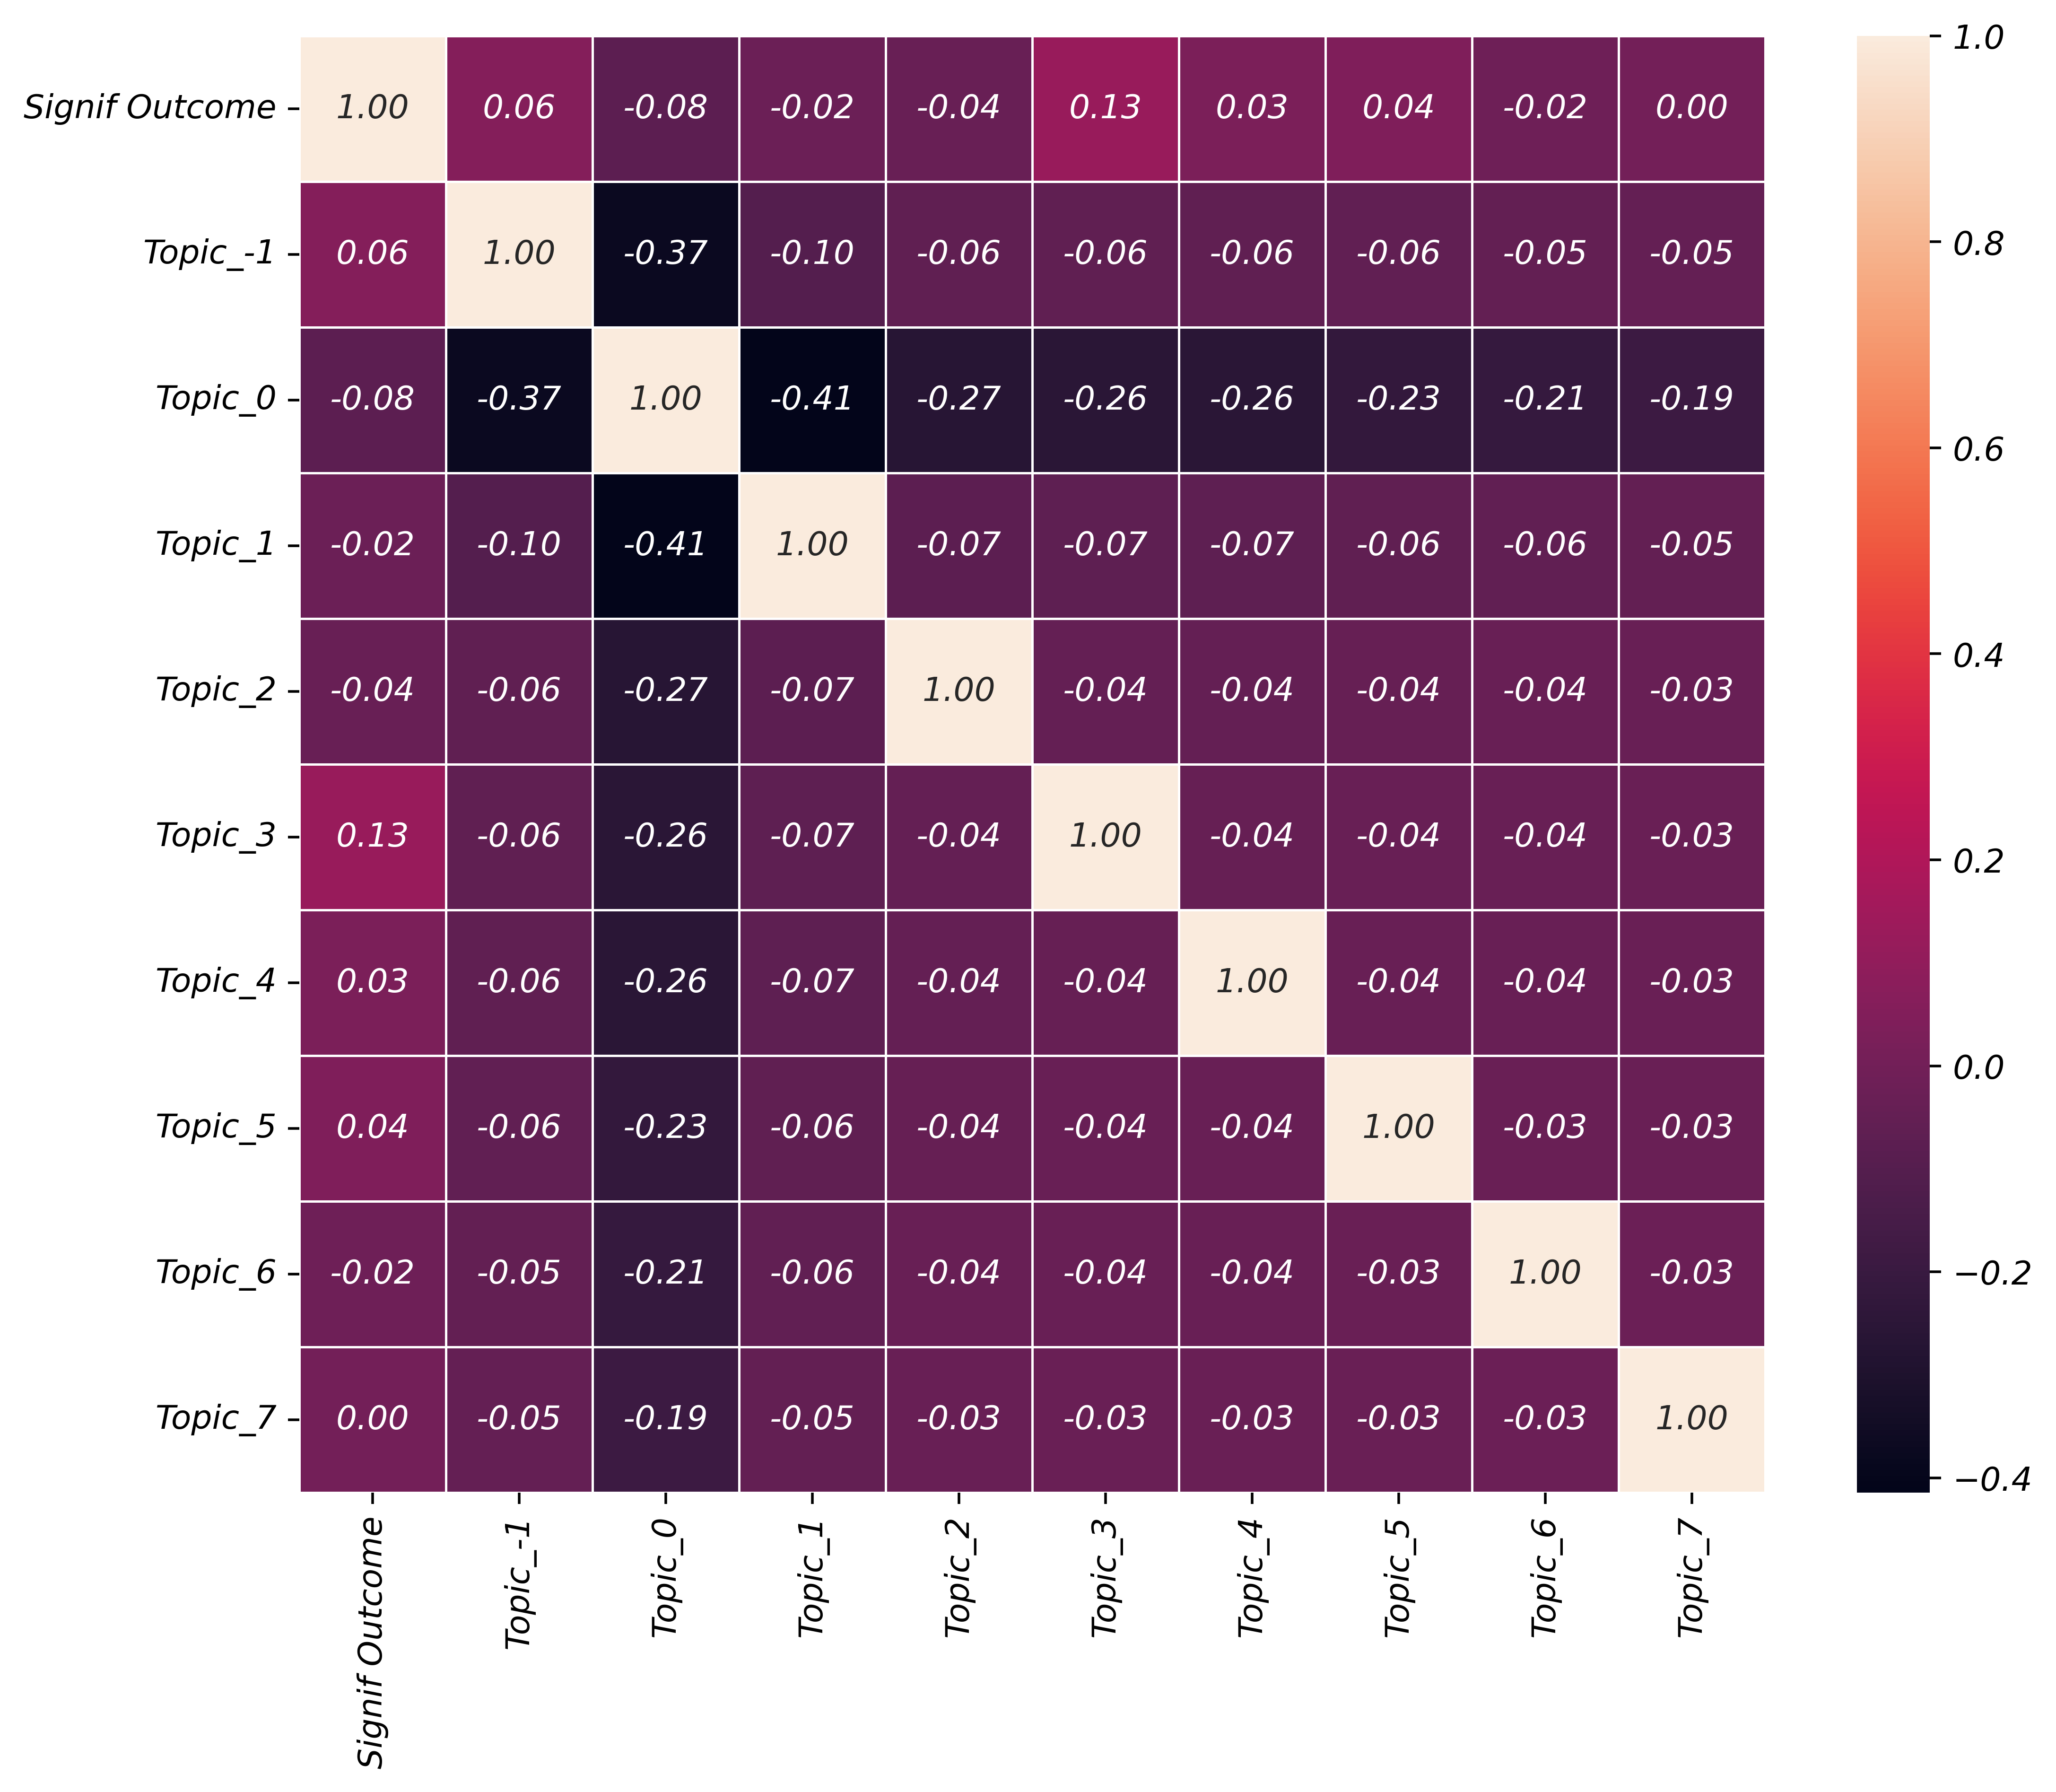

In [146]:
import seaborn as sns
# Printing the heatmap of the correlation matrix
topic_corr.rename(columns={'Protests with a significant outcome': 'Signif Outcome'}, inplace=True)
corr = topic_corr.corr(method = 'pearson')
plt.figure(figsize=(10,8), dpi =500)
sns.heatmap(corr,annot=True,fmt=".2f", linewidth=.5)
plt.show()

In [147]:
# Keeping only the topic that is the most correlated with our target variable
max_corr = 0
max_topic = ''
sign_list = corr['Signif Outcome'][1:]
indexes = sign_list.index

for i in range(len(sign_list)):
    curr_corr = sign_list[i]
    if curr_corr > max_corr:
        max_corr = curr_corr
        max_topic = indexes[i]
    else:
        continue

print(max_topic, max_corr)

lowered_cleaned_data = pd.concat([lowered_cleaned_data,topic_corr[max_topic]],axis=1)
lowered_cleaned_data[:1]

Topic_3 0.12517358356888664


,index,Country,Protest Name,Start Date,Freedom Rating (Status),Triggers,Motivations,Peak Size,Key Participants,Outcomes,...,Size category,Protests with a significant outcome,"Large protests (Over 100,000 protesting)",Violent government response,Long protests (more than 3 months),Coronavirus-related protests,Capital city,Duration in days,Free,Topic_3
0,0,Ecuador,protest for guayaquil four boys,2024-12-01,Partly Free,four teenage boys the guayaquil four disappear...,demand justice for missing boys express anger ...,100.0,general public families of missing boys,the nationwide protests pushed authorities to ...,...,1,0,0,0,0,0,Quito,94.0,0,0


### Repeating predictions after feature engineering

In [148]:
lowered_cleaned_data.columns

Index(['index', 'Country', 'Protest Name', 'Start Date',
       'Freedom Rating (Status)', 'Triggers', 'Motivations', 'Peak Size',
       'Key Participants', 'Outcomes', 'Active protests',
       'Economic motivation?', 'Political motivation?',
       'Corruption motivation?', 'Gender motivation?', 'Size category',
       'Protests with a significant outcome',
       'Large protests (Over 100,000 protesting)',
       'Violent government response', 'Long protests (more than 3 months)',
       'Coronavirus-related protests', 'Capital city', 'Duration in days',
       'Free', 'Topic_3'],
      dtype='object')

In [149]:
# Dropped columns that had the least feature importance
X_final = lowered_cleaned_data[['Peak Size', 'Duration in days','Economic motivation?', 'Political motivation?','Corruption motivation?',
                                'Violent government response', 'Free', max_topic]]
y_final = lowered_cleaned_data['Protests with a significant outcome']

In [150]:
from sklearn.preprocessing import StandardScaler

columns_to_normalize = ['Peak Size', 'Duration in days']
scaler = StandardScaler()
X_final[columns_to_normalize] = scaler.fit_transform(X_final[columns_to_normalize])

In [151]:
X_final

,Peak Size,Duration in days,Economic motivation?,Political motivation?,Corruption motivation?,Violent government response,Free,Topic_3
0,-0.217656,0.054640,0,1,0,0,0,0
1,-0.217656,-0.453487,0,1,0,0,0,0
2,-0.212729,-0.453487,0,1,0,0,0,0
3,-0.212729,-0.453487,1,0,0,0,0,0
4,-0.217656,-0.453487,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...
763,-0.212729,-0.131127,1,0,1,0,0,0
764,0.329163,2.846606,1,1,1,0,0,1
765,-0.053993,-0.453487,1,1,1,0,1,0
766,0.876529,0.032785,0,1,0,0,0,0


### Repeating the process of hyperparameter tuning

In [152]:
hyperparameter_tuning('dt', X_final, y_final)
hyperparameter_tuning('rf', X_final, y_final)
hyperparameter_tuning('xgb', X_final, y_final)

Tuned Decision Tree Parameters: {'criterion': 'gini', 'max_depth': 3, 'max_features': 4, 'min_samples_leaf': 4}
Tuned Random Forest Parameters: {'bootstrap': False, 'criterion': 'gini', 'max_depth': 3, 'max_features': 2, 'min_samples_leaf': 1, 'min_samples_split': 4}
Tuned XGBoost parameters {'colsample_bytree': 0.7, 'gamma': 0.0, 'learning_rate': 0.2, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 195, 'subsample': 0.7505895660696511}


In [153]:
xgb_model_2 = xgb.XGBClassifier(colsample_bytree=0.7, 
                                      gamma= 0.0, learning_rate= 0.2, 
                                      max_depth= 4, min_child_weight= 3, 
                                      n_estimators= 195, subsample= 0.7505895660696511)
        
rf_model_2 = RandomForestClassifier(n_estimators=50, bootstrap=False, criterion='gini', max_depth=3, max_features=2,
                            min_samples_leaf=1, min_samples_split=4)

dt_model_2 = DecisionTreeClassifier(criterion="gini", max_depth=3, 
                               max_features=4,min_samples_leaf=4)

Comparing with the best performing models before feature engineering

In [156]:
y_pred_xgb_20_False_2, y_test_xgb_20_False_2 = prediction(X_final,y_final,0.2,False,xgb_model_2)
best_threshold = choose_threshold(y_pred_xgb_20_False_2, y_test_xgb_20_False_2)
y_pred_binary_xgb_20_False_2, results = evaluate(y_pred_xgb_20_False_2, best_threshold, y_test_xgb_20_False_2)
results

For a test size of 0.2 the distribution of the target variable after duplication is:
 Protests with a significant outcome
0    503
1    333
Name: count, dtype: int64
                       Feature  Importance
1             Duration in days    0.159301
7                      Topic_3    0.141307
5  Violent government response    0.129158
0                    Peak Size    0.127754
3        Political motivation?    0.127608
2         Economic motivation?    0.115110
4       Corruption motivation?    0.108144
6                         Free    0.091618
Best threshold: 0.97, best f1-score: 0.5670103092783504, best accuracy: 0.45454545454545453


{'Accuracy': 0.45454545454545453,
 'Precision': 0.40441176470588236,
 'Recall': 0.9482758620689655,
 'f1': 0.5670103092783504}

In [198]:
y_pred_rf_30_True_2, y_test_rf_30_True_2 = prediction(X_final,y_final,0.3,True,rf_model_2)
best_threshold = choose_threshold(y_pred_rf_30_True_2, y_test_rf_30_True_2)
y_pred_binary_rf_30_True_2, results = evaluate(y_pred_rf_30_True_2, best_threshold, y_test_rf_30_True_2)
results

For a test size of 0.3 the distribution of the target variable after duplication is:
 Protests with a significant outcome
0    420
1    351
Name: count, dtype: int64
                       Feature  Importance
1             Duration in days    0.567729
0                    Peak Size    0.134802
4       Corruption motivation?    0.110285
5  Violent government response    0.054805
7                      Topic_3    0.048131
3        Political motivation?    0.039298
2         Economic motivation?    0.036271
6                         Free    0.008677
Best threshold: 0.54, best f1-score: 0.4914285714285714, best accuracy: 0.6147186147186147


{'Accuracy': 0.6147186147186147,
 'Precision': 0.34959349593495936,
 'Recall': 0.8269230769230769,
 'f1': 0.4914285714285714}

In [216]:
y_pred_dt_30_False_2, y_test_dt_30_False_2 = prediction(X_final,y_final,0.3,False,dt_model_2)
best_threshold = choose_threshold(y_pred_dt_30_False_2, y_test_dt_30_False_2)
y_pred_binary_dt_30_False_2, results = evaluate(y_pred_dt_30_False_2, best_threshold, y_test_dt_30_False_2)
results

For a test size of 0.3 the distribution of the target variable after duplication is:
 Protests with a significant outcome
0    449
1    264
Name: count, dtype: int64
                       Feature  Importance
1             Duration in days    0.656529
2         Economic motivation?    0.245647
5  Violent government response    0.087302
7                      Topic_3    0.007753
6                         Free    0.002769
0                    Peak Size    0.000000
3        Political motivation?    0.000000
4       Corruption motivation?    0.000000
Best threshold: 0.63, best f1-score: 0.5503875968992249, best accuracy: 0.49783549783549785


{'Accuracy': 0.49783549783549785,
 'Precision': 0.4011299435028249,
 'Recall': 0.8765432098765432,
 'f1': 0.5503875968992249}

Confusion matrix of the best model based on f1 

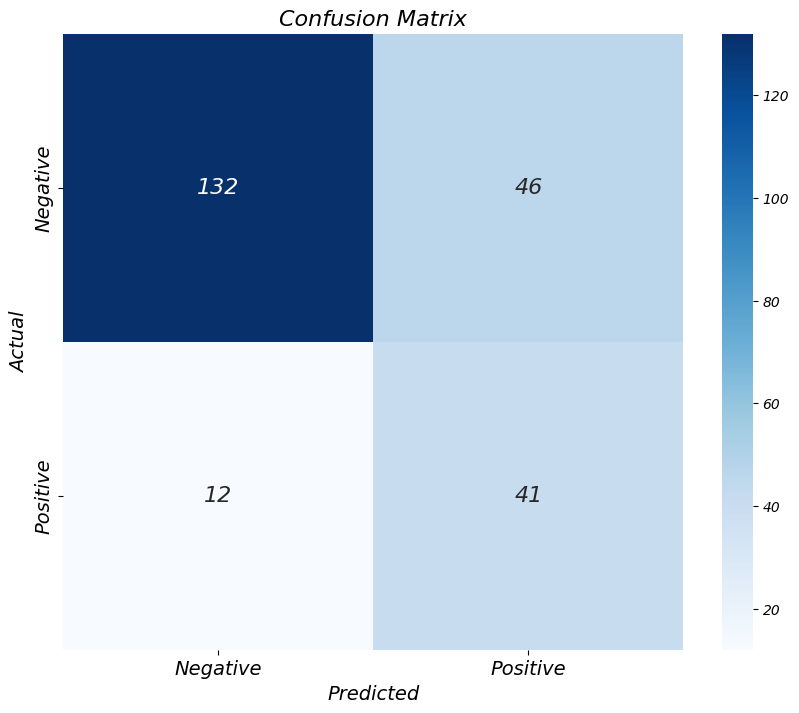

In [489]:
create_confusion_matrix(y_test_rf_30_True_1,y_pred_binary_rf_30_True_1)

## Explainability

In [99]:
xgb_model = xgb.XGBClassifier(
    colsample_bytree=0.7, 
    gamma=0.3, 
    learning_rate=0.05, 
    max_depth=9, 
    min_child_weight=7, 
    n_estimators=68, 
    subsample=0.8563277359652208
)

Using the best model for explainability for before Feature Engineering and after

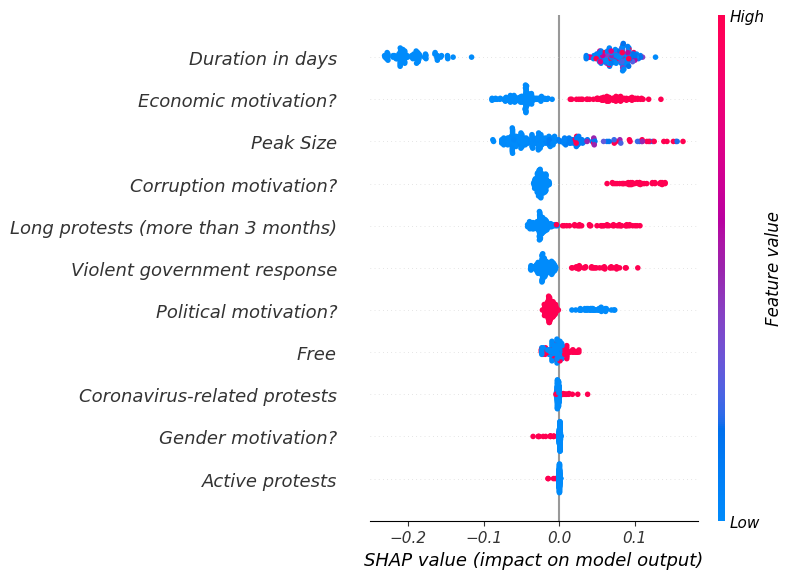

In [219]:
import shap 

X_train, X_test, y_train, y_test = train_test_split(cleaned_X, cleaned_y, test_size=0.3, shuffle=True)
        
# Identify rows to duplicate based on the target variable
rows_to_duplicate = X_train[y_train == 1]
    
# Duplicate the rows in both X_train and y_train
X_train = pd.concat([X_train, rows_to_duplicate, rows_to_duplicate], ignore_index=True)
y_train = pd.concat([y_train, y_train[y_train == 1], y_train[y_train == 1]], ignore_index=True)

rf_model_1.fit(X_train, y_train)
y_pred = rf_model_1.predict_proba(X_test)

explainer = shap.TreeExplainer(rf_model_1)
shap_values = explainer.shap_values(X_test)

# Taking only the shap values for the positive class
shap_values_positive = shap_values[:, :, 1]
# Summarizing the effects of all the features
shap.summary_plot(shap_values_positive,X_test)

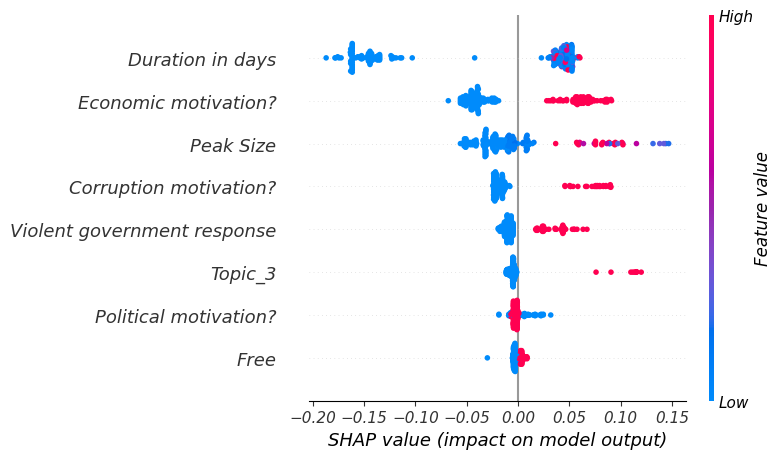

In [220]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.3, shuffle=True)
        
# Identify rows to duplicate based on the target variable
rows_to_duplicate = X_train[y_train == 1]
    
# Duplicate the rows in both X_train and y_train
X_train = pd.concat([X_train, rows_to_duplicate, rows_to_duplicate], ignore_index=True)
y_train = pd.concat([y_train, y_train[y_train == 1], y_train[y_train == 1]], ignore_index=True)

rf_model_2.fit(X_train, y_train)
y_pred = rf_model_2.predict_proba(X_test)

explainer = shap.TreeExplainer(rf_model_2)
shap_values = explainer.shap_values(X_test)

# Taking only the shap values for the positive class
shap_values_positive = shap_values[:, :, 1]
# Summarizing the effects of all the features
shap.summary_plot(shap_values_positive,X_test)

PCA

In [103]:
import plotly.express as px
from sklearn.datasets import make_classification

# PCA
X, y = make_classification(
    n_features=8,
    n_classes=2,
    n_samples=1500,
    n_informative=2,
    random_state=5,
    n_clusters_per_class=1,
)


fig = px.scatter_3d(x=X[:, 0], y=X[:, 1], z=X[:, 2], color=y, opacity=0.8)
fig.show()

In [285]:
from sklearn.manifold import TSNE

# TSNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)
tsne.kl_divergence_

fig = px.scatter(x=X_tsne[:, 0], y=X_tsne[:, 1], color=y)
fig.update_layout(
    title="t-SNE visualization",
    xaxis_title="First t-SNE",
    yaxis_title="Second t-SNE",
)
fig.show()

## Assessing Statistical Significance

In [250]:
# Should be dt
y_pred_binary_rf_30_True_1

array([0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0])

In [251]:
y_pred_binary_rf_30_True_2

array([1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1])

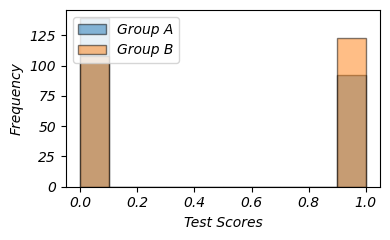

t-statistic:	-2.912
p-value:	0.0037700225633762055
p < 0.05: The difference between the two groups is significant


In [252]:
# Hypothetical test scores
group_A = y_pred_binary_rf_30_True_1 # Should be dt
group_B = y_pred_binary_rf_30_True_2

# Plot test scores of both groups
plt.figure(figsize=(4, 2.5))
plt.hist(group_A, alpha=0.5, label='Group A', edgecolor='black')
plt.hist(group_B, alpha=0.5, label='Group B', edgecolor='black')
plt.xlabel('Test Scores'); plt.ylabel('Frequency'); plt.legend(loc='upper left'); plt.tight_layout(); plt.show()

# Two-sample t-test
t_stat, p_value = stats.ttest_ind(group_A, group_B)

print(f"t-statistic:\t{t_stat:.3f}")
print(f"p-value:\t{p_value}")
if p_value < 0.05:
    print("p < 0.05: The difference between the two groups is significant")
else:
    print("p > 0.05: The difference between the two groups is not significant")

## Prediction - Part 2

In this section I will determine the target variable based on different NLP techniques. 

1. TF-IDF 

In [216]:
from sklearn.metrics.pairwise import cosine_similarity

# More preprocessing might be necessary in this case
# Initializing TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer()
vectorizer = TfidfVectorizer(strip_accents="ascii", lowercase=True, stop_words='english', ngram_range = (1,2), max_df = 0.99, min_df = 0.01, max_features=1000, norm = 'l2', binary = False)

# Fitting and transforming both columns (Motivations and Outcomes)
tfidf_motivations = tfidf_vectorizer.fit_transform(data['Motivations'])
tfidf_outcomes = tfidf_vectorizer.transform(data['Outcomes'])

# Computing cosine similarity between motivations and outcomes
similarity_scores = cosine_similarity(tfidf_motivations, tfidf_outcomes)

# Flattening diagonal of the similarity matrix (each row matches itself)
data['TF-IDF'] = [similarity_scores[i, i] for i in range(similarity_scores.shape[0])]
data[['Motivations','Outcomes','TF-IDF']]

,Motivations,Outcomes,TF-IDF
0,Denounce Özer's removal from office as a political coup. Call for the resignation of President Recep Tayyip Erdoğan’s government.,No policy/leadership change,0.000000
1,"Protest the election results, which many believe were rigged by the ruling party. Protesters are angry at the continuation of Frelimo's forty-nine-year rule, which has been marked by corruption and economic decline. They are also angry over the death of the two opposition figures.","No policy/leadership change. Police violently cracked down on the protests, firing tear gas and killing at least ten demonstrators.",0.044021
2,Call for Prime Minister Edi Rama to step down and for the government to be replaced by a caretaker cabinet before the 2025 parliamentary election. The opposition has repeatedly accused Rama and the Socialist Party of Albania of corruption.,No policy/leadership change.,0.000000
3,"Denounce the election results, which many—both within and outside Georgia—believe were the result of a flawed electoral process.",No policy/leadership change. Three out of the four main opposition parties refused to accept the election results and announced that they would not take their seats in Parliament. The Central Election Commission reaffirmed the election results on October 31 after conducting a partial recount of the votes.,0.183328
4,"Criticize the Supreme Court ruling, which protesters believe to be unconstitutional since same-sex marriage is not legal. Protesters are also opposed to the LGBTQ+ community and argue that anti-discriminatory laws will result in reverse discrimination.",No policy/leadership change.,0.000000
...,...,...,...
764,"Concerns over a lack of genuine political pluralism, allegations of electoral manipulation, and the entrenchment of Kenyatta.","Though the Supreme Court nullified the election’s results and called for a new contest, opposition leader Raila Odinga withdrew in protests and Kenyatta was proclaimed the victor.",0.162475
765,"Discontent with government policies on farming, lack of government assistance, and stagnating incomes for farmers.","There were a series of farmer protests in different states; in Maharashtra, the government promised to settle tribal farmers’ disputes over land ownership and to expand the loan-waiver scheme.",0.114427
766,"Economic challenges, inequality, corruption, political cronyism, and growing disapproval of then president Jacob Zuma.",No policy/leadership change in response to the protests.,0.000000
767,"Growing authoritarianism, economic crisis, and ensuing food and medicine shortages.",No policy/leadership change in response to the protests.,0.000000


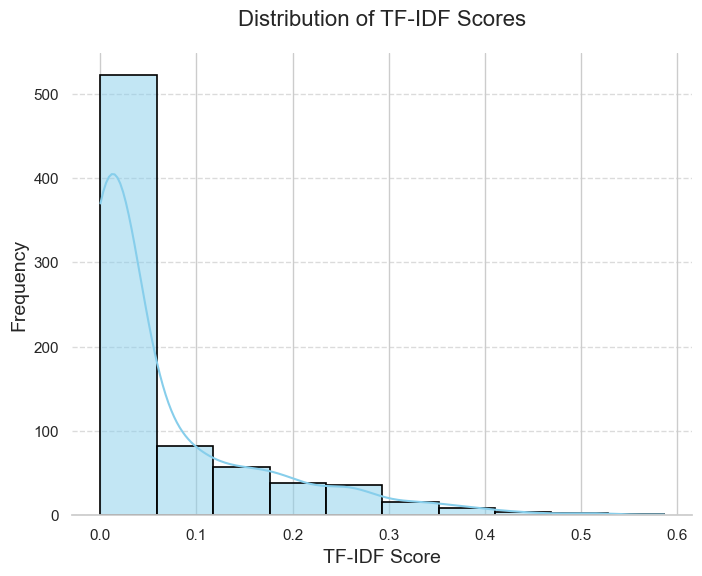

In [217]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_hist(column):
    sns.set(style="whitegrid")
    plt.figure(figsize=(8, 6))
    sns.histplot(data[column], bins=10, kde=True, color='skyblue', edgecolor='black', linewidth=1.2)
    
    plt.title(f'Distribution of {column} Scores', fontsize=16, pad=20)
    plt.xlabel(f'{column} Score', fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    
    sns.despine(left=True)  
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Example usage
plot_hist('TF-IDF')

In [510]:
def tf_idf(score):
    if score > 0.1:
        return 1
    else:
        return 0
    
data['TF-IDF'] = data['TF-IDF'].apply(tf_idf)

In [499]:
data['Protests with a significant outcome'].value_counts()

0    582
1    186
Name: Protests with a significant outcome, dtype: int64

In [511]:
data['TF-IDF'].value_counts()

0    588
1    180
Name: TF-IDF, dtype: int64

In [526]:
# Calculating the similarity between TF-IDF and the target variable
from sklearn.metrics import cohen_kappa_score

kappa_tf_idf = cohen_kappa_score(data['Protests with a significant outcome'], data['TF-IDF'])
print(kappa_tf_idf)

0.21093925128894864


2. VADER 

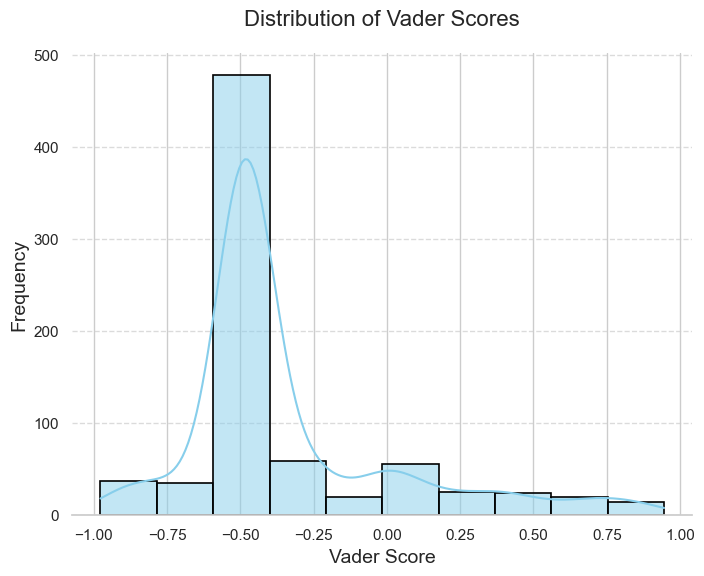

In [218]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# loading the VADER model of sentiment analysis
analyzer = SentimentIntensityAnalyzer()

def add_compound(row):
    score = analyzer.polarity_scores(row)
    return score['compound']

data['Vader'] = data['Outcomes'].apply(add_compound)
plot_hist('Vader')

In [524]:
def vader_binary(score):
    if score > 0:
        return 1
    else:
        return 0
    
data['Vader'] = data['Vader'].apply(vader_binary)
print(data['Protests with a significant outcome'].value_counts())
print(data['Vader'].value_counts())

0    582
1    186
Name: Protests with a significant outcome, dtype: int64
0    658
1    110
Name: Vader, dtype: int64


In [525]:
kappa_vader = cohen_kappa_score(data['Protests with a significant outcome'], data['Vader'])
print(kappa_vader)

0.21720097849877684


3. ABSA (Aspect-Based Sentiment Analysis)

In [527]:
from pyabsa import available_checkpoints
from pyabsa import ATEPCCheckpointManager

checkpoint_map = available_checkpoints()
aspect_extractor = ATEPCCheckpointManager.get_aspect_extractor(checkpoint='english',
                                                               auto_device=True) #False means load model on CPU

[2025-01-06 15:27:33] (2.4.1.post1) Please specify the task code, e.g. from pyabsa import TaskCodeOption
[2025-01-06 15:27:34] (2.4.1.post1) ********** Available ATEPC model checkpoints for Version:2.4.1.post1 (this version) **********
[2025-01-06 15:27:34] (2.4.1.post1) ********** Available ATEPC model checkpoints for Version:2.4.1.post1 (this version) **********
[2025-01-06 15:27:34] (2.4.1.post1) Downloading checkpoint:english 
[2025-01-06 15:27:34] (2.4.1.post1) Notice: The pretrained model are used for testing, it is recommended to train the model on your own custom datasets
[2025-01-06 15:27:34] (2.4.1.post1) Checkpoint already downloaded, skip
[2025-01-06 15:27:34] (2.4.1.post1) Load aspect extractor from checkpoints/ATEPC_ENGLISH_CHECKPOINT/fast_lcf_atepc_English_cdw_apcacc_82.36_apcf1_81.89_atef1_75.43
[2025-01-06 15:27:34] (2.4.1.post1) config: checkpoints/ATEPC_ENGLISH_CHECKPOINT/fast_lcf_atepc_English_cdw_apcacc_82.36_apcf1_81.89_atef1_75.43/fast_lcf_atepc.config
[2025-01-0

/Users/mayairemozbayoglu/anaconda3/lib/python3.11/site-packages/transformers/convert_slow_tokenizer.py:561: UserWarning:

The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.



In [574]:
example = ['Camera quality is very good but battery drains fast.']
inference_source = example
atepc_result = aspect_extractor.extract_aspect(inference_source=inference_source,
                                               pred_sentiment=True)

[2025-01-08 12:04:09] (2.4.1.post1) The results of aspect term extraction have been saved in /Users/mayairemozbayoglu/Documents/Research Paper/Aspect Term Extraction and Polarity Classification.FAST_LCF_ATEPC.result.json
[2025-01-08 12:04:09] (2.4.1.post1) Example 0: Camera quality is very good but <battery:Negative Confidence:0.9986> drains fast .


In [576]:
atepc_result[0]['sentence']

'Camera quality is very good but battery drains fast .'

In [577]:
Positive = []
Neutral = []

def absa_binary(outcome):
    protest = [outcome]
    inference_source = protest
    atepc_result = aspect_extractor.extract_aspect(inference_source=inference_source,
                                               pred_sentiment=True)
    sentiment_list = atepc_result[0]['sentiment']
    sentence = atepc_result[0]['sentence']
    if 'Positive' in sentiment_list:
        Positive.append(sentence)
        return 1
    elif 'Neutral' in sentiment_list: 
        Neutral.append(sentence)
        return 1
    else:
        return 0
    
data['ABSA'] = data['Outcomes'].apply(absa_binary)
print(data['Protests with a significant outcome'].value_counts())
print(data['ABSA'].value_counts())
kappa_absa = cohen_kappa_score(data['Protests with a significant outcome'], data['ABSA'])
print(kappa_absa)

[2025-01-08 12:06:45] (2.4.1.post1) The results of aspect term extraction have been saved in /Users/mayairemozbayoglu/Documents/Research Paper/Aspect Term Extraction and Polarity Classification.FAST_LCF_ATEPC.result.json
[2025-01-08 12:06:45] (2.4.1.post1) Example 0: No policy / leadership change
[2025-01-08 12:06:46] (2.4.1.post1) The results of aspect term extraction have been saved in /Users/mayairemozbayoglu/Documents/Research Paper/Aspect Term Extraction and Polarity Classification.FAST_LCF_ATEPC.result.json
[2025-01-08 12:06:46] (2.4.1.post1) Example 0: No policy / leadership change . <Police:Negative Confidence:0.9983> violently cracked down on the protests , firing tear gas and killing at least ten demonstrators .
[2025-01-08 12:06:47] (2.4.1.post1) The results of aspect term extraction have been saved in /Users/mayairemozbayoglu/Documents/Research Paper/Aspect Term Extraction and Polarity Classification.FAST_LCF_ATEPC.result.json
[2025-01-08 12:06:47] (2.4.1.post1) Example 0: 

In [579]:
Positive

['The government scrapped plans to eliminate the diesel tax break for agricultural vehicles and announced a series of measures to ease financial and administrative burdens placed upon farmers . Prime Minister Gabriel Attal also confirmed France would remain opposed to the EU signing a free - trade agreement with the Mercosur trade group . In April 2024 , the EU approved legislation that eased the environmental rules of the Common Agricultural Policy ( CAP ) . In September 2024 , the European Commission announced that EU member states could increase the CAP funds provided to farmers .',
 'The prime minister apologized for any responsibility that the government had borne for the accident . He promised a swift investigation and said the new transportation minister would release a safety improvement plan . He also promised to name a commission to investigate mismanagement of the country ’ s railway system .',
 "On June 12 , the government announced that it will raise teachers ' pay by 25 p

In [580]:
Neutral

['No policy / leadership change . Three out of the four main opposition parties refused to accept the election results and announced that they would not take their seats in Parliament . The Central Election Commission reaffirmed the election results on October 31 after conducting a partial recount of the votes .',
 'Counterprotesters , most of whom were supporters of the Chega party , demonstrated in defense of the police . On October 25 , the officer who killed Moniz was indicted on murder charges .',
 'Demonstrators reached an agreement with the Ministry of Environment , which included commitments to advance the formalization of the mining sector and promote sustainable mining practices .',
 "No political party agreed to form a coalition government with the FPÖ . As such , President Alexander Van der Bellen asked incumbent Chancellor Karl Nehammer and his party , the conservative Austrian People ' s Party , to form a government .",
 'To prevent further demonstrations , the Karachi go